✓ curve_db loaded with 437226 isogeny classes
Combined CY families (HV + Bicubic)
  Rank 0: 371 curves  (HV 194 + BC 177)
  Rank 1: 308 curves  (HV 162 + BC 146)

Database pool: 168760 rank 0, 222439 rank 1

FAMILY FIT  (first 100 primes)
  Rank 0: A=0.3244, α=0.2586, χ²=28.6637
  Rank 1: A=-0.3729, α=0.2443, χ²=38.5509
  Total χ² = 67.2146

Running 200 random draws...

RANDOM BASELINE  (200/200 successful fits)
  Mean χ²  = 146.7891
  Std  χ²  = 17.2898
  Min  χ²  = 103.6364
  Max  χ²  = 214.8065

COMPARISON
  Family χ²          = 67.2146
  Random mean χ²     = 146.7891
  Ratio (rand/fam)   = 2.18x
  z-score            = 4.60

  → Combined CY families are 2.18x cleaner than random


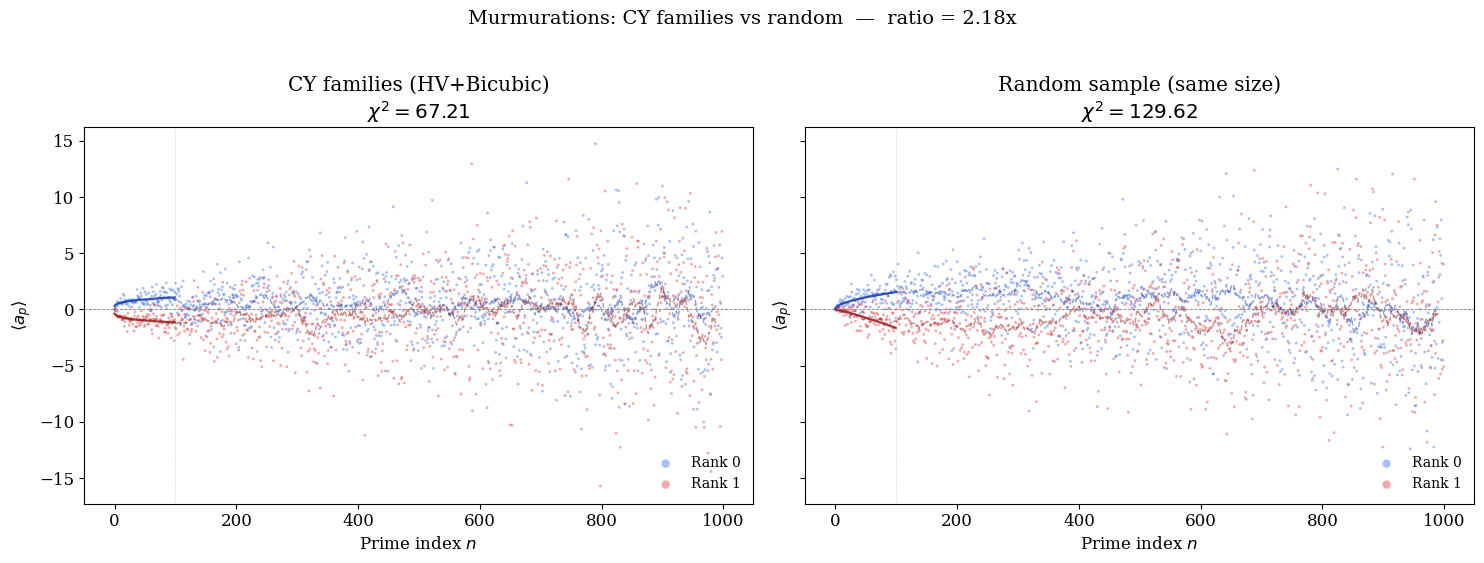


Plot saved to Fast_Murmuration_Search/CY_combined_vs_random.png


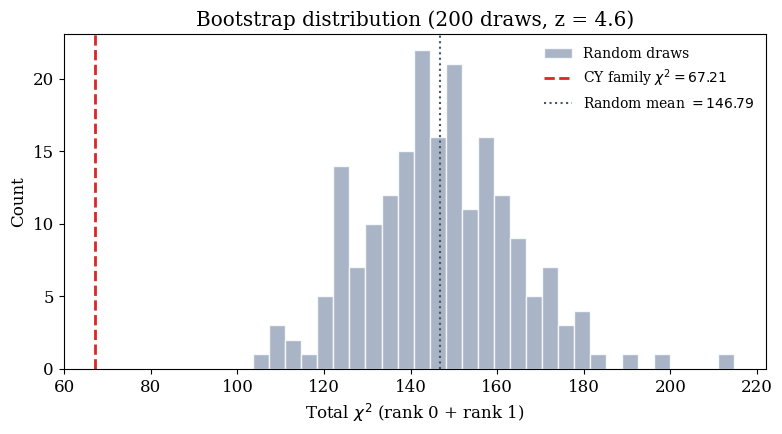

Histogram saved to Fast_Murmuration_Search/CY_combined_chi2_distribution.png

Summary saved to Fast_Murmuration_Search/CY_combined_vs_random_summary.sobj


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.optimize import curve_fit
import builtins
float, int = builtins.float, builtins.int

output_dir = 'Fast_Murmuration_Search'
os.makedirs(output_dir, exist_ok=True)

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

# ── load family data ──────────────────────────────────────────────
HV_data  = load(f'{output_dir}/HV_avg_aps.sobj')
BC_data  = load(f'{output_dir}/BICUBIC_avg_aps.sobj')

HV_a0, HV_a1 = HV_data['rk0_avg'], HV_data['rk1_avg']
BC_a0, BC_a1 = BC_data['rk0_avg'], BC_data['rk1_avg']
HV_n0, HV_n1 = HV_data['n0'], HV_data['n1']
BC_n0, BC_n1 = BC_data['n0'], BC_data['n1']

n0_combined = HV_n0 + BC_n0
n1_combined = HV_n1 + BC_n1

combined_a0 = (HV_a0 * HV_n0 + BC_a0 * BC_n0) / n0_combined
combined_a1 = (HV_a1 * HV_n1 + BC_a1 * BC_n1) / n1_combined

print(f"Combined CY families (HV + Bicubic)")
print(f"  Rank 0: {n0_combined} curves  (HV {HV_n0} + BC {BC_n0})")
print(f"  Rank 1: {n1_combined} curves  (HV {HV_n1} + BC {BC_n1})")

# ── random sample ─────────────────────────────────────────────────
N_RANDOM_DRAWS = 200   # bootstrap iterations
SEED = int(42)
N_FIT = 100            # primes used for fit

def power_law(x, A, alpha):
    return A * x**alpha

rk0_isos = [iso for iso, d in curve_db.items() if d['rank'] == 0]
rk1_isos = [iso for iso, d in curve_db.items() if d['rank'] == 1]

print(f"\nDatabase pool: {len(rk0_isos)} rank 0, {len(rk1_isos)} rank 1")

x_fit = np.arange(1, N_FIT + 1, dtype=float)

# ── helper: fit + chi² ───────────────────────────────────────────
def fit_chi2(avg_data, p0):
    """Power-law fit on first N_FIT points, return chi²."""
    y = np.array(avg_data[:N_FIT], dtype=float)
    popt, _ = curve_fit(power_law, x_fit, y, p0=p0, maxfev=10000)
    residuals = y - power_law(x_fit, *popt)
    return np.sum(residuals**2), popt

# ── fit combined family ──────────────────────────────────────────
chi2_fam_rk0, popt_fam_rk0 = fit_chi2(combined_a0, p0=[-1, 0.5])
chi2_fam_rk1, popt_fam_rk1 = fit_chi2(combined_a1, p0=[ 1, 0.5])
chi2_fam_total = chi2_fam_rk0 + chi2_fam_rk1

print(f"\n{'='*60}")
print(f"FAMILY FIT  (first {N_FIT} primes)")
print(f"{'='*60}")
print(f"  Rank 0: A={popt_fam_rk0[0]:.4f}, α={popt_fam_rk0[1]:.4f}, χ²={chi2_fam_rk0:.4f}")
print(f"  Rank 1: A={popt_fam_rk1[0]:.4f}, α={popt_fam_rk1[1]:.4f}, χ²={chi2_fam_rk1:.4f}")
print(f"  Total χ² = {chi2_fam_total:.4f}")

# ── bootstrap random draws ───────────────────────────────────────
print(f"\nRunning {N_RANDOM_DRAWS} random draws...")
rng = random.Random(SEED)
chi2_rand_totals = []

for trial in range(N_RANDOM_DRAWS):
    rk0_sample = rng.sample(rk0_isos, int(n0_combined))
    rk1_sample = rng.sample(rk1_isos, int(n1_combined))
    
    rk0_avg_r = np.mean([curve_db[iso]['ap_list'] for iso in rk0_sample], axis=0)
    rk1_avg_r = np.mean([curve_db[iso]['ap_list'] for iso in rk1_sample], axis=0)
    
    try:
        c0, _ = fit_chi2(rk0_avg_r, p0=[-1, 0.5])
        c1, _ = fit_chi2(rk1_avg_r, p0=[ 1, 0.5])
        chi2_rand_totals.append(c0 + c1)
    except RuntimeError:
        continue  # fit failed, skip this draw

chi2_rand_arr = np.array(chi2_rand_totals)
chi2_rand_mean = np.mean(chi2_rand_arr)
chi2_rand_std  = np.std(chi2_rand_arr)

print(f"\n{'='*60}")
print(f"RANDOM BASELINE  ({len(chi2_rand_totals)}/{N_RANDOM_DRAWS} successful fits)")
print(f"{'='*60}")
print(f"  Mean χ²  = {chi2_rand_mean:.4f}")
print(f"  Std  χ²  = {chi2_rand_std:.4f}")
print(f"  Min  χ²  = {np.min(chi2_rand_arr):.4f}")
print(f"  Max  χ²  = {np.max(chi2_rand_arr):.4f}")

ratio_mean = chi2_rand_mean / chi2_fam_total
z_score = (chi2_rand_mean - chi2_fam_total) / chi2_rand_std

print(f"\n{'='*60}")
print(f"COMPARISON")
print(f"{'='*60}")
print(f"  Family χ²          = {chi2_fam_total:.4f}")
print(f"  Random mean χ²     = {chi2_rand_mean:.4f}")
print(f"  Ratio (rand/fam)   = {ratio_mean:.2f}x")
print(f"  z-score            = {z_score:.2f}")
print(f"\n  → Combined CY families are {ratio_mean:.2f}x cleaner than random")

# ── single representative random draw for plotting ───────────────
rng_plot = random.Random(SEED)
rk0_plot_sample = rng_plot.sample(rk0_isos, int(n0_combined))
rk1_plot_sample = rng_plot.sample(rk1_isos, int(n1_combined))
rk0_avg_rand = np.mean([curve_db[iso]['ap_list'] for iso in rk0_plot_sample], axis=0)
rk1_avg_rand = np.mean([curve_db[iso]['ap_list'] for iso in rk1_plot_sample], axis=0)
chi2_rand_rk0_plot, popt_rand_rk0 = fit_chi2(rk0_avg_rand, p0=[-1, 0.5])
chi2_rand_rk1_plot, popt_rand_rk1 = fit_chi2(rk1_avg_rand, p0=[ 1, 0.5])
chi2_rand_plot = chi2_rand_rk0_plot + chi2_rand_rk1_plot

# ── plot: side-by-side comparison ─────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.linewidth': float(0.8),
    'figure.facecolor': 'white',
})

n_primes = len(combined_a0)
primes_idx = np.arange(n_primes, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, (a0, a1, label, chi2_tot, p0, p1) in zip(axes, [
    (combined_a0, combined_a1,
     f'CY families (HV+Bicubic)\n$\\chi^2 = {chi2_fam_total:.2f}$',
     chi2_fam_total, popt_fam_rk0, popt_fam_rk1),
    (rk0_avg_rand, rk1_avg_rand,
     f'Random sample (same size)\n$\\chi^2 = {chi2_rand_plot:.2f}$',
     chi2_rand_plot, popt_rand_rk0, popt_rand_rk1),
]):
    ax.scatter(primes_idx, a0, s=int(4), alpha=float(0.4),
               color='#2563eb', edgecolors='none', label='Rank 0')
    ax.scatter(primes_idx, a1, s=int(4), alpha=float(0.4),
               color='#dc2626', edgecolors='none', label='Rank 1')
    
    # power-law fits
    ax.plot(x_fit - 1, power_law(x_fit, *p0), color='#1e40af',
            lw=float(1.6), alpha=float(0.85))
    ax.plot(x_fit - 1, power_law(x_fit, *p1), color='#991b1b',
            lw=float(1.6), alpha=float(0.85))
    
    # running means
    window = 25
    kernel = np.ones(window) / window
    for data, color in [(a0, '#1e40af'), (a1, '#991b1b')]:
        smooth = np.convolve(np.array(data, dtype=float), kernel, mode='valid')
        ax.plot(primes_idx[window//2 : window//2 + len(smooth)],
                smooth, color=color, lw=float(1.0), alpha=float(0.5), ls='--')
    
    ax.axhline(0, color='grey', lw=float(0.6), ls='--')
    ax.axvline(N_FIT, color='grey', lw=float(0.5), ls=':', alpha=float(0.5))
    ax.set_xlabel('Prime index $n$')
    ax.set_ylabel(r'$\langle a_p \rangle$')
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=int(10), markerscale=int(3), loc='lower right')

fig.suptitle(
    f'Murmurations: CY families vs random  —  ratio = {ratio_mean:.2f}x',
    fontsize=int(14), y=float(1.02)
)
fig.tight_layout()

plot_path = f'{output_dir}/CY_combined_vs_random.png'
plt.savefig(plot_path, bbox_inches='tight', dpi=int(200))
plt.show()
print(f"\nPlot saved to {plot_path}")

# ── plot: bootstrap distribution ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 4.5))
ax2.hist(chi2_rand_arr, bins=int(30), color='#94a3b8', edgecolor='white',
         alpha=float(0.8), label='Random draws')
ax2.axvline(chi2_fam_total, color='#dc2626', lw=float(2), ls='--',
            label=f'CY family $\\chi^2 = {chi2_fam_total:.2f}$')
ax2.axvline(chi2_rand_mean, color='#475569', lw=float(1.5), ls=':',
            label=f'Random mean $= {chi2_rand_mean:.2f}$')
ax2.set_xlabel(r'Total $\chi^2$ (rank 0 + rank 1)')
ax2.set_ylabel('Count')
ax2.set_title(f'Bootstrap distribution ({N_RANDOM_DRAWS} draws, z = {z_score:.1f})')
ax2.legend(frameon=False, fontsize=int(10))
fig2.tight_layout()

hist_path = f'{output_dir}/CY_combined_chi2_distribution.png'
plt.savefig(hist_path, bbox_inches='tight', dpi=int(200))
plt.show()
print(f"Histogram saved to {hist_path}")

# ── save summary ──────────────────────────────────────────────────
summary = {
    'families': ['Hulek-Verrill', 'Bicubic'],
    'n0': n0_combined, 'n1': n1_combined,
    'N_FIT': N_FIT,
    'family_chi2_rk0': chi2_fam_rk0,
    'family_chi2_rk1': chi2_fam_rk1,
    'family_chi2_total': chi2_fam_total,
    'family_fit_rk0': {'A': popt_fam_rk0[0], 'alpha': popt_fam_rk0[1]},
    'family_fit_rk1': {'A': popt_fam_rk1[0], 'alpha': popt_fam_rk1[1]},
    'random_chi2_mean': chi2_rand_mean,
    'random_chi2_std': chi2_rand_std,
    'ratio': ratio_mean,
    'z_score': z_score,
    'N_RANDOM_DRAWS': N_RANDOM_DRAWS,
}
save(summary, f'{output_dir}/CY_combined_vs_random_summary.sobj')
print(f"\nSummary saved to {output_dir}/CY_combined_vs_random_summary.sobj")

In [2]:
"""
Complete suite for analyzing elliptic curve families and comparing to random samples.
Includes bootstrapped chi² distribution and conductor-range splitting.
"""
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter
import random
from scipy.optimize import curve_fit

os.makedirs('Fast_Murmuration_Search', exist_ok=True)

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100000)/curve_database_N1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")


# ============================================================================
# HELPERS
# ============================================================================

def get_isogeny_class(label):
    """Extract isogeny class from curve label: '11a1' -> '11a'"""
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]


def get_conductor(iso_label):
    """Extract integer conductor from isogeny class label: '11a' -> 11"""
    i = 0
    while i < len(iso_label) and iso_label[i].isdigit():
        i += 1
    return int(iso_label[:i])


def power_law(x, A, alpha):
    """Power law function: A * x^alpha"""
    return A * x**alpha


def fit_power_law(y, n_fit, p0, label=""):
    """
    Fit power law to first n_fit points of y.
    Returns dict with A, alpha, chi2, fit array, or None on failure.
    """
    if len(y) < n_fit:
        return None
    x = np.arange(1, n_fit + 1)
    data = y[:n_fit]
    try:
        popt, _ = curve_fit(power_law, x, data, p0=p0, maxfev=10000)
        A, alpha = popt
        fit = power_law(x, A, alpha)
        chi2 = float(np.sum((data - fit)**2))
        return {'A': A, 'alpha': alpha, 'chi2': chi2, 'fit': fit, 'popt': popt}
    except Exception as e:
        if label:
            print(f"  Fit failed for {label}: {e}")
        return None


def compute_total_chi2(rk0_avg, rk1_avg, n0, n1, n_fit):
    """Compute total chi2 from power-law fits to rank 0 and rank 1 averages."""
    res_rk0 = fit_power_law(rk0_avg, n_fit, p0=[-1, 0.5]) if n0 > 0 else None
    res_rk1 = fit_power_law(rk1_avg, n_fit, p0=[1, 0.5]) if n1 > 0 else None
    chi2 = 0.0
    if res_rk0 is not None:
        chi2 += res_rk0['chi2']
    if res_rk1 is not None:
        chi2 += res_rk1['chi2']
    return chi2, res_rk0, res_rk1


# ============================================================================
# FAMILY DEFINITION
# ============================================================================

class EllipticCurveFamily:
    """
    Define an elliptic curve family E: y^2 = x^3 + a(phi)*x + b(phi)

    Parameters
    ----------
    a_coeffs : dict  {power: coefficient}
    b_coeffs : dict  {power: coefficient}
    name : str
    """
    def __init__(self, a_coeffs, b_coeffs, name="CustomFamily"):
        self.a_coeffs = a_coeffs
        self.b_coeffs = b_coeffs
        self.name = name

        R.<phi> = QQ[]
        self.a_poly = sum(c * phi^p for p, c in a_coeffs.items())
        self.b_poly = sum(c * phi^p for p, c in b_coeffs.items())

        print(f"Family: {name}")
        print(f"  a(φ) = {self.a_poly}")
        print(f"  b(φ) = {self.b_poly}")

    def curve(self, phi_val):
        """Return EllipticCurve for a given rational phi."""
        return EllipticCurve([0, 0, 0, self.a_poly(phi_val), self.b_poly(phi_val)])


# ============================================================================
# SCAN FAMILY
# ============================================================================

def scan_family(family, phi_range_m=(-20, 21), phi_range_n=(-20, 21)):
    """
    Scan phi = m/n grid, collect isogeny classes and ap data from curve_db.
    Returns dict with iso_to_phis, iso_to_data (including conductor), ap lists, stats.
    """
    phis = set()
    for m in range(*phi_range_m):
        for n in range(*phi_range_n):
            if n != 0:
                phis.add(QQ(m) / QQ(n))
    phis = list(phis)
    print(f"Generated {len(phis)} unique phi values")

    iso_to_phis = {}
    iso_to_data = {}
    n_hits = 0
    n_misses = 0

    for phi in tqdm(phis, desc="Scanning"):
        try:
            E = family.curve(phi)
            iso = get_isogeny_class(E.label())
            if iso in curve_db:
                if iso not in iso_to_phis:
                    iso_to_phis[iso] = []
                    c = curve_db[iso]
                    iso_to_data[iso] = {
                        'rank': c['rank'],
                        'aps': c['ap_list'],
                        'conductor': get_conductor(iso),
                    }
                iso_to_phis[iso].append(phi)
                n_hits += 1
            else:
                n_misses += 1
        except Exception:
            n_misses += 1

    n_distinct = len(iso_to_phis)
    efficiency = 100.0 * n_hits / len(phis) if phis else 0

    rk0_aps = [d['aps'] for d in iso_to_data.values() if d['rank'] == 0]
    rk1_aps = [d['aps'] for d in iso_to_data.values() if d['rank'] == 1]

    print(f"\n{'='*60}")
    print(f"SCAN RESULTS: {family.name}")
    print(f"{'='*60}")
    print(f"Phis tried: {len(phis)}  |  Hits: {n_hits}  |  Misses: {n_misses}")
    print(f"Efficiency: {efficiency:.1f}%")
    print(f"Distinct isogeny classes: {n_distinct}  (redundant: {n_hits - n_distinct})")
    print(f"Rank 0: {len(rk0_aps)}  |  Rank 1: {len(rk1_aps)}")

    conductors = [d['conductor'] for d in iso_to_data.values()]
    if conductors:
        print(f"Conductor range: {min(conductors)} – {max(conductors)}")

    mults = Counter(len(v) for v in iso_to_phis.values())
    print("Multiplicity distribution:")
    for m in sorted(mults):
        print(f"  {m}x: {mults[m]}")

    return {
        'iso_to_phis': iso_to_phis,
        'iso_to_data': iso_to_data,
        'rk0_aps': rk0_aps,
        'rk1_aps': rk1_aps,
        'stats': {
            'n_phis': len(phis), 'n_hits': n_hits,
            'n_misses': n_misses, 'n_distinct': n_distinct,
            'efficiency': efficiency,
        },
    }


# ============================================================================
# BOOTSTRAP COMPARISON
# ============================================================================

def bootstrap_random_chi2(n0, n1, n_fit, n_bootstrap=200, seed=42,
                          cond_range=None):
    """
    Draw n_bootstrap random samples from curve_db and return array of total chi2.

    Parameters
    ----------
    cond_range : tuple (lo, hi) or None
        If given, restrict the random pool to conductors in [lo, hi).
    """
    if cond_range is not None:
        lo, hi = cond_range
        rk0_pool = [iso for iso, d in curve_db.items()
                     if d['rank'] == 0 and lo <= get_conductor(iso) < hi]
        rk1_pool = [iso for iso, d in curve_db.items()
                     if d['rank'] == 1 and lo <= get_conductor(iso) < hi]
    else:
        rk0_pool = [iso for iso, d in curve_db.items() if d['rank'] == 0]
        rk1_pool = [iso for iso, d in curve_db.items() if d['rank'] == 1]

    actual_n0 = min(n0, len(rk0_pool))
    actual_n1 = min(n1, len(rk1_pool))
    if actual_n0 < n0 or actual_n1 < n1:
        print(f"  ⚠ Pool limited: using {actual_n0}/{n0} rk0, {actual_n1}/{n1} rk1")
    if actual_n0 + actual_n1 == 0:
        return np.array([])

    rng = random.Random(int(seed))
    chi2_samples = []

    for _ in tqdm(range(int(n_bootstrap)), desc="Bootstrap"):
        chi2 = 0.0
        if actual_n0 > 0:
            avg = np.mean([curve_db[iso]['ap_list']
                           for iso in rng.sample(rk0_pool, actual_n0)], axis=0)
            res = fit_power_law(avg, n_fit, p0=[-1, 0.5])
            if res is not None:
                chi2 += res['chi2']
        if actual_n1 > 0:
            avg = np.mean([curve_db[iso]['ap_list']
                           for iso in rng.sample(rk1_pool, actual_n1)], axis=0)
            res = fit_power_law(avg, n_fit, p0=[1, 0.5])
            if res is not None:
                chi2 += res['chi2']
        chi2_samples.append(chi2)

    return np.array(chi2_samples)


# ============================================================================
# CONDUCTOR-SPLIT ANALYSIS
# ============================================================================

def conductor_split_analysis(scan, family_name, n_fit=100,
                             conductor_bins=None, n_bootstrap=200, seed=42,
                             output_dir='Fast_Murmuration_Search'):
    """
    Split family curves by conductor range and compare murmuration patterns.

    Parameters
    ----------
    scan : dict
        Output of scan_family().
    family_name : str
    n_fit : int
        Number of primes to fit.
    conductor_bins : list of tuples, or None
        List of (lo, hi) conductor ranges.  If None, splits at the median
        conductor into two equal-size bins.
    n_bootstrap : int
        Number of random draws per bin for bootstrap comparison.
    seed : int
    output_dir : str
    """
    tag = family_name.replace(" ", "_")
    iso_to_data = scan['iso_to_data']

    # Collect conductors
    all_conds = sorted([d['conductor'] for d in iso_to_data.values()])
    if len(all_conds) < 20:
        print("⚠ Too few curves for a meaningful conductor split.")
        return None

    # Default: two bins split at the median
    if conductor_bins is None:
        median_cond = int(np.median(all_conds))
        conductor_bins = [
            (min(all_conds), median_cond),
            (median_cond, max(all_conds) + 1),
        ]
        print(f"Splitting at median conductor N = {median_cond}")

    n_bins = len(conductor_bins)
    bin_results = []

    for k, (lo, hi) in enumerate(conductor_bins):
        print(f"\n{'─'*60}")
        print(f"BIN {k+1}/{n_bins}:  N ∈ [{lo}, {hi})")
        print(f"{'─'*60}")

        # Select curves in this bin
        rk0_aps = [d['aps'] for d in iso_to_data.values()
                   if d['rank'] == 0 and lo <= d['conductor'] < hi]
        rk1_aps = [d['aps'] for d in iso_to_data.values()
                   if d['rank'] == 1 and lo <= d['conductor'] < hi]
        n0, n1 = len(rk0_aps), len(rk1_aps)
        print(f"  Rank 0: {n0}  |  Rank 1: {n1}")

        if n0 + n1 < 5:
            print("  Skipping — too few curves.")
            bin_results.append(None)
            continue

        rk0_avg = np.mean(rk0_aps, axis=0) if n0 > 0 else np.array([])
        rk1_avg = np.mean(rk1_aps, axis=0) if n1 > 0 else np.array([])

        available = []
        if n0 > 0:
            available.append(len(rk0_avg))
        if n1 > 0:
            available.append(len(rk1_avg))
        N_FIT = min(int(n_fit), *available)

        chi2_fam, f0, f1 = compute_total_chi2(rk0_avg, rk1_avg, n0, n1, N_FIT)
        print(f"  Family χ² = {chi2_fam:.2f}")
        if f0 is not None:
            print(f"    rk0: {f0['A']:.4f} · i^{f0['alpha']:.4f}  χ²={f0['chi2']:.2f}")
        if f1 is not None:
            print(f"    rk1: {f1['A']:.4f} · i^{f1['alpha']:.4f}  χ²={f1['chi2']:.2f}")

        # Bootstrap within same conductor range
        chi2_rand = bootstrap_random_chi2(n0, n1, N_FIT,
                                           n_bootstrap=n_bootstrap, seed=seed,
                                           cond_range=(lo, hi))
        median_rand = float(np.median(chi2_rand)) if len(chi2_rand) > 0 else None
        p_val = float(np.mean(chi2_rand <= chi2_fam)) if len(chi2_rand) > 0 else None

        if median_rand is not None:
            print(f"  Random χ² median = {median_rand:.2f}")
            if chi2_fam > 0:
                print(f"  Cleanliness = {median_rand / chi2_fam:.2f}x")
            print(f"  p-value = {p_val:.4f}")

        # Save per-bin averages
        bin_save_path = f'{output_dir}/{tag}_cond_{lo}_{hi}_avg_aps.sobj'
        save({'rk0_avg': rk0_avg, 'rk1_avg': rk1_avg,
              'n0': n0, 'n1': n1,
              'conductor_range': (lo, hi),
              'family_name': family_name,
              'chi2_family': chi2_fam,
              'chi2_random': chi2_rand,
              'fit_rk0': f0, 'fit_rk1': f1,
              'n_fit': N_FIT}, bin_save_path)
        print(f"  Saved bin data to {bin_save_path}")

        bin_results.append({
            'lo': lo, 'hi': hi,
            'n0': n0, 'n1': n1,
            'rk0_avg': rk0_avg, 'rk1_avg': rk1_avg,
            'fit_rk0': f0, 'fit_rk1': f1,
            'chi2_family': chi2_fam,
            'chi2_random': chi2_rand,
            'median_random_chi2': median_rand,
            'p_value': p_val,
            'n_fit': N_FIT,
            'save_path': bin_save_path,
        })

    # ========================================================================
    # PLOTS
    # ========================================================================

    valid = [(k, r) for k, r in enumerate(bin_results) if r is not None]
    if len(valid) == 0:
        print("No bins had enough curves to plot.")
        return bin_results

    # --- Plot A: side-by-side murmuration by conductor bin ---
    fig, axes = plt.subplots(1, len(valid), figsize=(8 * len(valid), 6),
                             squeeze=False, sharey=True)
    axes = axes[0]

    for j, (k, r) in enumerate(valid):
        ax = axes[j]
        x_all = np.arange(1, max(len(r['rk0_avg']) if r['n0'] > 0 else 0,
                                  len(r['rk1_avg']) if r['n1'] > 0 else 0) + 1)
        x_fit = np.arange(1, r['n_fit'] + 1)

        if r['n0'] > 0:
            ax.scatter(x_all[:len(r['rk0_avg'])], r['rk0_avg'],
                       s=8, alpha=0.6, label=f"Rank 0 (n={r['n0']})")
            if r['fit_rk0'] is not None:
                ax.plot(x_fit, r['fit_rk0']['fit'], 'b-', lw=2)
        if r['n1'] > 0:
            ax.scatter(x_all[:len(r['rk1_avg'])], r['rk1_avg'],
                       s=8, alpha=0.6, label=f"Rank 1 (n={r['n1']})")
            if r['fit_rk1'] is not None:
                ax.plot(x_fit, r['fit_rk1']['fit'], 'r-', lw=2)

        ax.axhline(0, color='gray', ls='--', alpha=0.3)
        ax.axvline(r['n_fit'], color='gray', ls=':', alpha=0.5)
        ax.set_xlabel('Prime index $i$', fontsize=13)
        ax.set_title(f"N ∈ [{r['lo']}, {r['hi']})  (χ²={r['chi2_family']:.1f})",
                     fontsize=13)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r'Average $a_{p_i}$', fontsize=13)
    fig.suptitle(f'{family_name}: Murmuration by Conductor Range', fontsize=15, y=1.02)
    plt.tight_layout()
    path_split = f'{output_dir}/{tag}_conductor_split.png'
    plt.savefig(path_split, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {path_split}")

    # --- Plot B: overlay rank-0 (or rank-1) from each bin to see period shift ---
    for rank_label, rank_val, color_cycle in [
        ('Rank 0', 0, plt.cm.Blues(np.linspace(0.4, 0.9, len(valid)))),
        ('Rank 1', 1, plt.cm.Reds(np.linspace(0.4, 0.9, len(valid)))),
    ]:
        has_data = any(r[f'n{rank_val}'] > 0 for _, r in valid)
        if not has_data:
            continue

        plt.figure(figsize=(14, 6))
        for j, (k, r) in enumerate(valid):
            avg_key = f'rk{rank_val}_avg'
            if r[f'n{rank_val}'] == 0:
                continue
            avg = r[avg_key]
            x = np.arange(1, len(avg) + 1)
            plt.scatter(x, avg, s=8, alpha=0.5, color=color_cycle[j],
                        label=f"N ∈ [{r['lo']}, {r['hi']})  n={r[f'n{rank_val}']}")

        plt.axhline(0, color='gray', ls='--', alpha=0.3)
        plt.xlabel('Prime index $i$', fontsize=13)
        plt.ylabel(r'Average $a_{p_i}$', fontsize=13)
        plt.title(f'{family_name} — {rank_label}: Conductor Dependence', fontsize=14)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        path_overlay = f'{output_dir}/{tag}_conductor_overlay_rk{rank_val}.png'
        plt.savefig(path_overlay, dpi=150)
        plt.show()
        print(f"Saved {path_overlay}")

    # --- Plot C: bootstrap histograms per bin ---
    fig, axes = plt.subplots(1, len(valid), figsize=(7 * len(valid), 5),
                             squeeze=False)
    axes = axes[0]

    for j, (k, r) in enumerate(valid):
        ax = axes[j]
        if r['chi2_random'] is not None and len(r['chi2_random']) > 0:
            ax.hist(r['chi2_random'], bins=25, density=True, alpha=0.7,
                    color='steelblue', edgecolor='white')
        ax.axvline(r['chi2_family'], color='crimson', lw=2.5, ls='--',
                   label=f"Family χ²={r['chi2_family']:.1f}")
        if r['median_random_chi2'] is not None:
            ax.axvline(r['median_random_chi2'], color='steelblue', lw=1.5, ls=':',
                       label=f"Median rand={r['median_random_chi2']:.1f}")
        pstr = f"p={r['p_value']:.3f}" if r['p_value'] is not None else ""
        ax.set_title(f"N ∈ [{r['lo']}, {r['hi']})  {pstr}", fontsize=13)
        ax.set_xlabel('Total χ²', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('Probability density', fontsize=12)
    fig.suptitle(f'{family_name}: Bootstrap χ² by Conductor Bin', fontsize=14, y=1.02)
    plt.tight_layout()
    path_boot_split = f'{output_dir}/{tag}_conductor_bootstrap.png'
    plt.savefig(path_boot_split, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {path_boot_split}")

    # --- Summary table ---
    print(f"\n{'='*70}")
    print(f"CONDUCTOR SPLIT SUMMARY — {family_name}")
    print(f"{'='*70}")
    print(f"{'Bin':>20s} {'n0':>5s} {'n1':>5s} {'χ²_fam':>8s} {'χ²_rand':>8s} "
          f"{'ratio':>7s} {'p-val':>7s}")
    print(f"{'─'*70}")
    for k, r in valid:
        ratio_str = (f"{r['median_random_chi2']/r['chi2_family']:.2f}x"
                     if r['chi2_family'] > 0 and r['median_random_chi2'] is not None
                     else "—")
        p_str = f"{r['p_value']:.4f}" if r['p_value'] is not None else "—"
        print(f"[{r['lo']:>6d}, {r['hi']:>6d})  {r['n0']:>5d} {r['n1']:>5d} "
              f"{r['chi2_family']:>8.1f} "
              f"{r['median_random_chi2']:>8.1f} " if r['median_random_chi2'] is not None else "",
              end="")
        # reprint cleanly
    # Cleaner table
    for k, r in valid:
        med = r['median_random_chi2']
        cf = r['chi2_family']
        ratio_s = f"{med/cf:.2f}x" if cf > 0 and med is not None else "—"
        p_s = f"{r['p_value']:.4f}" if r['p_value'] is not None else "—"
        med_s = f"{med:.1f}" if med is not None else "—"
        print(f"  N ∈ [{r['lo']}, {r['hi']}):  "
              f"n=({r['n0']},{r['n1']})  "
              f"χ²_fam={cf:.1f}  χ²_rand={med_s}  "
              f"ratio={ratio_s}  p={p_s}")

    return bin_results


# ============================================================================
# MAIN DRIVER
# ============================================================================

def run_family_analysis(family_name, a_coeffs, b_coeffs,
                        phi_range_m=(-20, 21), phi_range_n=(-20, 21),
                        n_fit=100, n_bootstrap=200, seed=42,
                        conductor_bins=None, do_conductor_split=True,
                        output_dir='Fast_Murmuration_Search'):
    """
    Full pipeline:
      1. Define family  →  2. Scan  →  3. Fit  →  4. Bootstrap
      →  5. Conductor-split analysis  →  6. Plots

    Parameters
    ----------
    conductor_bins : list of (lo, hi) tuples or None
        Custom conductor bins.  None → automatic median split.
    do_conductor_split : bool
        Whether to run the conductor-split analysis (step 5).
    """
    # --- Create family ---
    try:
        family = EllipticCurveFamily(a_coeffs, b_coeffs, name=family_name)
    except Exception as e:
        print(f"❌ Failed to create family: {e}")
        return None

    tag = family_name.replace(" ", "_")

    # --- Step 1: Scan ---
    print(f"\n{'='*60}")
    print(f"STEP 1: SCANNING {family_name}")
    print(f"{'='*60}")

    scan = scan_family(family, phi_range_m=phi_range_m, phi_range_n=phi_range_n)
    n0 = len(scan['rk0_aps'])
    n1 = len(scan['rk1_aps'])

    if n0 + n1 < 10:
        print(f"\n❌ Only {n0 + n1} curves found — too few for murmuration analysis.")
        print("Try expanding phi ranges or checking coefficient formulas.")
        return None

    rk0_avg = np.mean(scan['rk0_aps'], axis=0) if n0 > 0 else np.array([])
    rk1_avg = np.mean(scan['rk1_aps'], axis=0) if n1 > 0 else np.array([])

    # Save averages
    save_path = f'{output_dir}/{tag}_avg_aps.sobj'
    save({'rk0_avg': rk0_avg, 'rk1_avg': rk1_avg,
          'n0': n0, 'n1': n1,
          'family_name': family_name,
          'a_coeffs': a_coeffs, 'b_coeffs': b_coeffs}, save_path)
    print(f"Saved averages to {save_path}")

    # --- Step 2: Fit family ---
    print(f"\n{'='*60}")
    print(f"STEP 2: FITTING {family_name}")
    print(f"{'='*60}")

    available = []
    if n0 > 0:
        available.append(len(rk0_avg))
    if n1 > 0:
        available.append(len(rk1_avg))
    N_FIT = min(int(n_fit), *available)

    chi2_fam, fit_rk0, fit_rk1 = compute_total_chi2(rk0_avg, rk1_avg, n0, n1, N_FIT)

    if fit_rk0 is not None:
        print(f"Rank 0: {fit_rk0['A']:.4f} · i^{fit_rk0['alpha']:.4f}  (χ²={fit_rk0['chi2']:.2f})")
    if fit_rk1 is not None:
        print(f"Rank 1: {fit_rk1['A']:.4f} · i^{fit_rk1['alpha']:.4f}  (χ²={fit_rk1['chi2']:.2f})")
    print(f"Total family χ² = {chi2_fam:.2f}")

    # --- Step 3: Bootstrap ---
    print(f"\n{'='*60}")
    print(f"STEP 3: BOOTSTRAP ({n_bootstrap} random draws)")
    print(f"{'='*60}")

    chi2_rand = bootstrap_random_chi2(n0, n1, N_FIT,
                                       n_bootstrap=n_bootstrap, seed=seed)

    if len(chi2_rand) == 0:
        print("❌ Bootstrap failed.")
        return None

    median_rand = float(np.median(chi2_rand))
    mean_rand = float(np.mean(chi2_rand))
    std_rand = float(np.std(chi2_rand))
    p_value = float(np.mean(chi2_rand <= chi2_fam))

    print(f"\nRandom χ² distribution ({n_bootstrap} draws):")
    print(f"  mean  = {mean_rand:.2f}  ±  {std_rand:.2f}")
    print(f"  median = {median_rand:.2f}")
    print(f"  min   = {float(np.min(chi2_rand)):.2f}  |  max = {float(np.max(chi2_rand)):.2f}")
    print(f"\nFamily χ² = {chi2_fam:.2f}")
    if chi2_fam > 0:
        print(f"Median random / family = {median_rand / chi2_fam:.2f}x cleaner")
    print(f"p-value (fraction of random ≤ family χ²) = {p_value:.4f}")

    # Save bootstrap data
    boot_path = f'{output_dir}/{tag}_bootstrap.sobj'
    save({'chi2_family': chi2_fam, 'chi2_random': chi2_rand,
          'n_bootstrap': int(n_bootstrap), 'n_fit': N_FIT,
          'n0': n0, 'n1': n1, 'seed': int(seed),
          'fit_rk0': fit_rk0, 'fit_rk1': fit_rk1}, boot_path)
    print(f"Saved bootstrap data to {boot_path}")

    # --- Step 4: Plots ---
    print(f"\n{'='*60}")
    print("STEP 4: PLOTTING")
    print(f"{'='*60}")

    x_fit = np.arange(1, N_FIT + 1)

    # Plot A: Family data with power-law fits
    n_primes = max(len(rk0_avg) if n0 > 0 else 0, len(rk1_avg) if n1 > 0 else 0)
    x_all = np.arange(1, n_primes + 1)

    plt.figure(figsize=(14, 6))
    if n0 > 0:
        plt.scatter(x_all[:len(rk0_avg)], rk0_avg, s=8, alpha=0.6,
                    label=f'Rank 0 (n={n0})')
        if fit_rk0 is not None:
            plt.plot(x_fit, fit_rk0['fit'], 'b-', lw=2,
                     label=f"Fit: {fit_rk0['A']:.3f} i^{fit_rk0['alpha']:.3f}")
    if n1 > 0:
        plt.scatter(x_all[:len(rk1_avg)], rk1_avg, s=8, alpha=0.6,
                    label=f'Rank 1 (n={n1})')
        if fit_rk1 is not None:
            plt.plot(x_fit, fit_rk1['fit'], 'r-', lw=2,
                     label=f"Fit: {fit_rk1['A']:.3f} i^{fit_rk1['alpha']:.3f}")
    plt.axhline(0, color='gray', ls='--', alpha=0.3)
    plt.axvline(N_FIT, color='gray', ls=':', alpha=0.5, label=f'Fit range (i<{N_FIT})')
    plt.xlabel('Prime index $i$', fontsize=13)
    plt.ylabel(r'Average $a_{p_i}$', fontsize=13)
    plt.title(f'{family_name}: Power-Law Fits (first {N_FIT} primes)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path_fit = f'{output_dir}/{tag}_power_law_fit.png'
    plt.savefig(path_fit, dpi=150)
    plt.show()
    print(f"Saved {path_fit}")

    # Plot B: Side-by-side family vs one random draw
    rng_plot = random.Random(int(seed))
    rk0_pool = [iso for iso, d in curve_db.items() if d['rank'] == 0]
    rk1_pool = [iso for iso, d in curve_db.items() if d['rank'] == 1]

    rk0_avg_r = np.array([])
    rk1_avg_r = np.array([])
    if n0 > 0:
        rk0_avg_r = np.mean([curve_db[iso]['ap_list']
                              for iso in rng_plot.sample(rk0_pool, n0)], axis=0)
    if n1 > 0:
        rk1_avg_r = np.mean([curve_db[iso]['ap_list']
                              for iso in rng_plot.sample(rk1_pool, n1)], axis=0)
    chi2_one_rand, fit_rk0_r, fit_rk1_r = compute_total_chi2(
        rk0_avg_r, rk1_avg_r, n0, n1, N_FIT)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    for ax, (r0a, r1a, f0, f1, chi2_val, title_str) in zip(
        axes,
        [(rk0_avg, rk1_avg, fit_rk0, fit_rk1, chi2_fam, f'{family_name}'),
         (rk0_avg_r, rk1_avg_r, fit_rk0_r, fit_rk1_r, chi2_one_rand, 'Random Sample')]):

        if n0 > 0:
            ax.scatter(np.arange(1, len(r0a)+1), r0a, s=8, alpha=0.6, label='Rank 0')
            if f0 is not None:
                ax.plot(x_fit, f0['fit'], 'b-', lw=2)
        if n1 > 0:
            ax.scatter(np.arange(1, len(r1a)+1), r1a, s=8, alpha=0.6, label='Rank 1')
            if f1 is not None:
                ax.plot(x_fit, f1['fit'], 'r-', lw=2)
        ax.axhline(0, color='gray', ls='--', alpha=0.3)
        ax.axvline(N_FIT, color='gray', ls=':', alpha=0.5)
        ax.set_xlabel('Prime index', fontsize=13)
        ax.set_title(f'{title_str} (χ²={chi2_val:.1f})', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Average $a_p$', fontsize=13)
    plt.tight_layout()
    path_cmp = f'{output_dir}/{tag}_vs_random.png'
    plt.savefig(path_cmp, dpi=150)
    plt.show()
    print(f"Saved {path_cmp}")

    # Plot C: Bootstrap histogram
    plt.figure(figsize=(10, 6))
    plt.hist(chi2_rand, bins=30, density=True, alpha=0.7, color='steelblue',
             edgecolor='white', label=f'Random draws (n={int(n_bootstrap)})')
    plt.axvline(chi2_fam, color='crimson', lw=2.5, ls='--',
                label=f'{family_name}  χ²={chi2_fam:.1f}')
    plt.axvline(median_rand, color='steelblue', lw=1.5, ls=':',
                label=f'Median random  χ²={median_rand:.1f}')
    plt.xlabel('Total χ² (power-law residual)', fontsize=13)
    plt.ylabel('Probability density', fontsize=13)
    plt.title(f'{family_name} vs Random: Bootstrap χ² Distribution '
              f'(p={p_value:.3f})', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path_boot = f'{output_dir}/{tag}_bootstrap_chi2.png'
    plt.savefig(path_boot, dpi=150)
    plt.show()
    print(f"Saved {path_boot}")

    # --- Step 5: Conductor-split analysis ---
    cond_split = None
    if do_conductor_split:
        print(f"\n{'='*60}")
        print("STEP 5: CONDUCTOR-SPLIT ANALYSIS")
        print(f"{'='*60}")

        cond_split = conductor_split_analysis(
            scan, family_name,
            n_fit=n_fit,
            conductor_bins=conductor_bins,
            n_bootstrap=n_bootstrap,
            seed=seed,
            output_dir=output_dir,
        )

    # --- Final summary ---
    print(f"\n{'='*60}")
    print(f"✓ COMPLETE — {family_name}")
    print(f"{'='*60}")
    print(f"Curves: {n0} rank 0, {n1} rank 1")
    print(f"Family χ²  = {chi2_fam:.2f}")
    print(f"Random χ²  = {median_rand:.2f} (median of {int(n_bootstrap)} draws)")
    if chi2_fam > 0:
        print(f"Cleanliness = {median_rand / chi2_fam:.2f}x")
    print(f"p-value    = {p_value:.4f}")

    return {
        'scan': scan,
        'fit_rk0': fit_rk0,
        'fit_rk1': fit_rk1,
        'chi2_family': chi2_fam,
        'chi2_random_samples': chi2_rand,
        'median_random_chi2': median_rand,
        'p_value': p_value,
        'n0': n0, 'n1': n1, 'n_fit': N_FIT,
        'conductor_split': cond_split,
    }


# ============================================================================
# READY
# ============================================================================
print("\n" + "="*60)
print("MURMURATION SUITE READY")
print("="*60)
print("""
Usage:
    result = run_family_analysis(
        "Hulek-Verrill",
        a_coeffs={...},
        b_coeffs={...},
        phi_range_m=(-30, 31),
        phi_range_n=(-30, 31),
        n_fit=100,
        n_bootstrap=200,
        # conductor_bins=[(11, 5000), (5000, 100000)],  # custom bins
        # do_conductor_split=True,                       # on by default
    )

Or run conductor split separately on existing scan data:
    cond = conductor_split_analysis(
        result['scan'], "Hulek-Verrill",
        conductor_bins=[(11, 1000), (1000, 10000), (10000, 100000)],
    )
""")

Loading curve database...
✓ Loaded curve_db with 437226 isogeny classes

MURMURATION SUITE READY

Usage:
    result = run_family_analysis(
        "Hulek-Verrill",
        a_coeffs={...},
        b_coeffs={...},
        phi_range_m=(-30, 31),
        phi_range_n=(-30, 31),
        n_fit=100,
        n_bootstrap=200,
        # conductor_bins=[(11, 5000), (5000, 100000)],  # custom bins
        # do_conductor_split=True,                       # on by default
    )

Or run conductor split separately on existing scan data:
    cond = conductor_split_analysis(
        result['scan'], "Hulek-Verrill",
        conductor_bins=[(11, 1000), (1000, 10000), (10000, 100000)],
    )



Family: HV
  a(φ) = -243*phi^4 + 324*phi^3 - 810*phi^2 + 324*phi - 27
  b(φ) = -1458*phi^6 + 2916*phi^5 + 7290*phi^4 - 9720*phi^3 + 5346*phi^2 - 972*phi + 54

STEP 1: SCANNING HV
Generated 511 unique phi values


Scanning: 100%|███████████████████████████████████████████████████████████████████████| 511/511 [00:46<00:00, 10.99it/s]



SCAN RESULTS: HV
Phis tried: 511  |  Hits: 427  |  Misses: 84
Efficiency: 83.6%
Distinct isogeny classes: 363  (redundant: 64)
Rank 0: 194  |  Rank 1: 162
Conductor range: 14 – 99484
Multiplicity distribution:
  1x: 308
  2x: 49
  3x: 4
  4x: 1
  5x: 1
Saved averages to Fast_Murmuration_Search/HV_avg_aps.sobj

STEP 2: FITTING HV
Rank 0: 0.3649 · i^0.2199  (χ²=53.40)
Rank 1: -0.5106 · i^0.1622  (χ²=98.31)
Total family χ² = 151.71

STEP 3: BOOTSTRAP (200 random draws)


Bootstrap: 100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:05<00:00, 33.99it/s]



Random χ² distribution (200 draws):
  mean  = 275.96  ±  30.65
  median = 275.77
  min   = 183.47  |  max = 359.10

Family χ² = 151.71
Median random / family = 1.82x cleaner
p-value (fraction of random ≤ family χ²) = 0.0000
Saved bootstrap data to Fast_Murmuration_Search/HV_bootstrap.sobj

STEP 4: PLOTTING


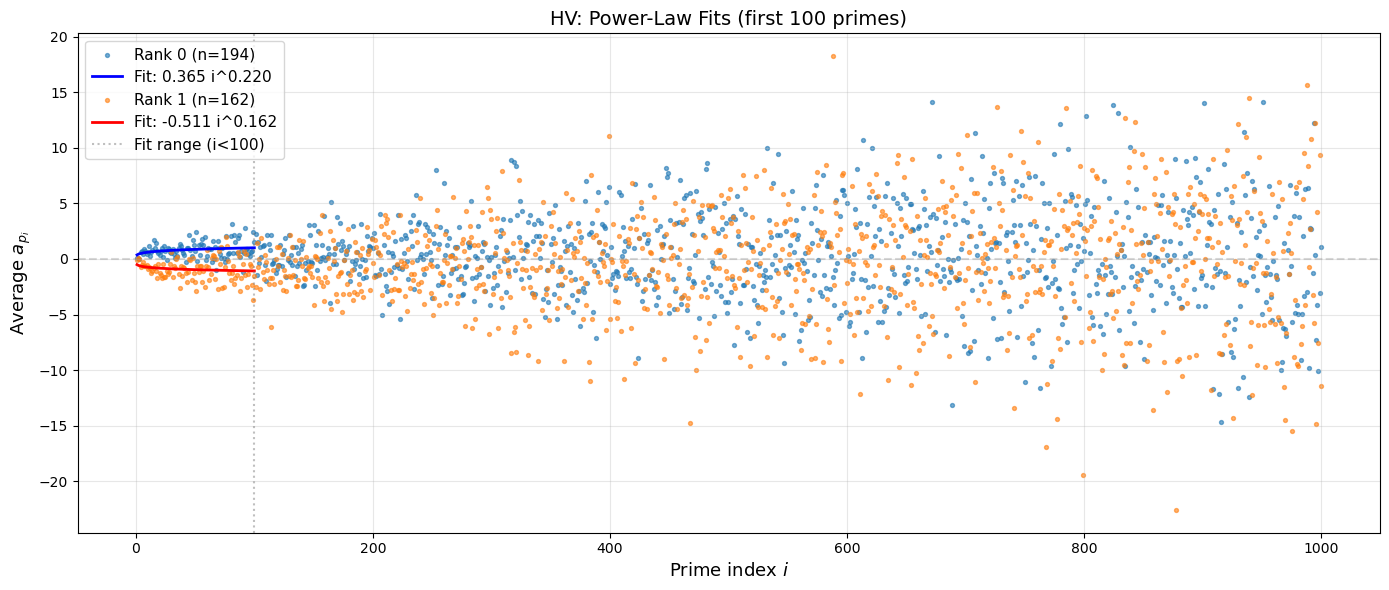

Saved Fast_Murmuration_Search/HV_power_law_fit.png


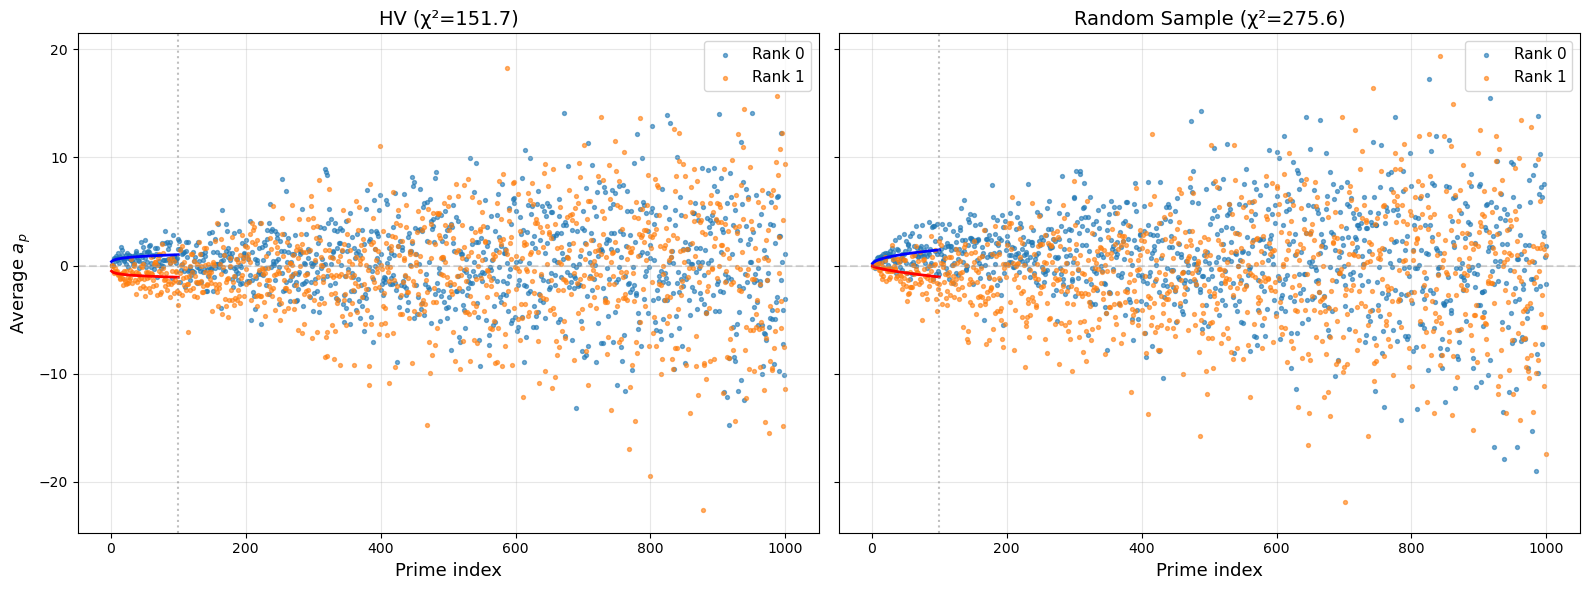

Saved Fast_Murmuration_Search/HV_vs_random.png


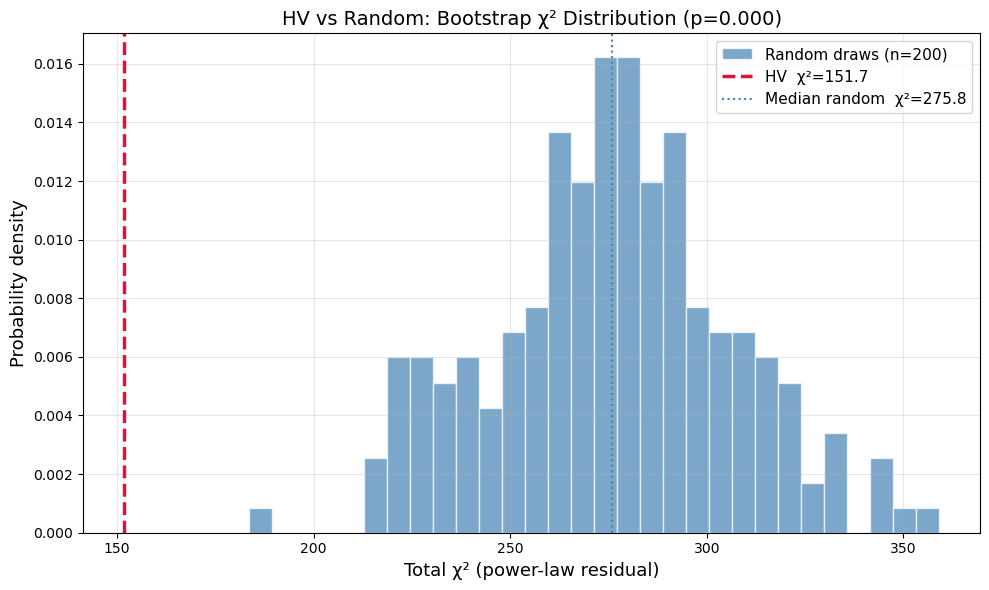

Saved Fast_Murmuration_Search/HV_bootstrap_chi2.png

STEP 5: CONDUCTOR-SPLIT ANALYSIS
Splitting at median conductor N = 10998

────────────────────────────────────────────────────────────
BIN 1/2:  N ∈ [14, 10998)
────────────────────────────────────────────────────────────
  Rank 0: 111  |  Rank 1: 70
  Family χ² = 419.41
    rk0: 0.5830 · i^-0.0424  χ²=71.16
    rk1: -1.3033 · i^-0.1149  χ²=348.25


Bootstrap: 100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 62.83it/s]


  Random χ² median = 571.54
  Cleanliness = 1.36x
  p-value = 0.0100
  Saved bin data to Fast_Murmuration_Search/HV_cond_14_10998_avg_aps.sobj

────────────────────────────────────────────────────────────
BIN 2/2:  N ∈ [10998, 99485)
────────────────────────────────────────────────────────────
  Rank 0: 83  |  Rank 1: 92
  Family χ² = 422.30
    rk0: 0.2252 · i^0.4543  χ²=194.54
    rk1: -0.0574 · i^0.7302  χ²=227.75


Bootstrap: 100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 62.17it/s]


  Random χ² median = 545.92
  Cleanliness = 1.29x
  p-value = 0.0100
  Saved bin data to Fast_Murmuration_Search/HV_cond_10998_99485_avg_aps.sobj


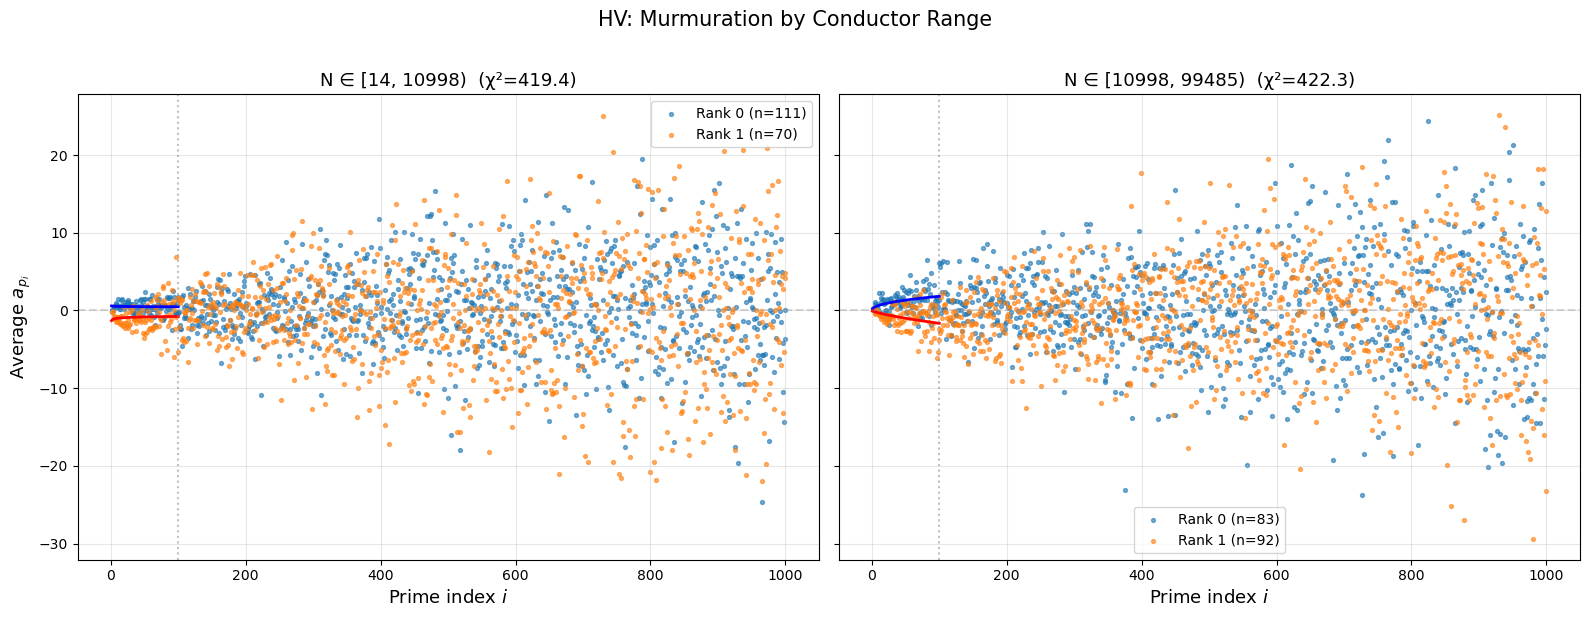

Saved Fast_Murmuration_Search/HV_conductor_split.png


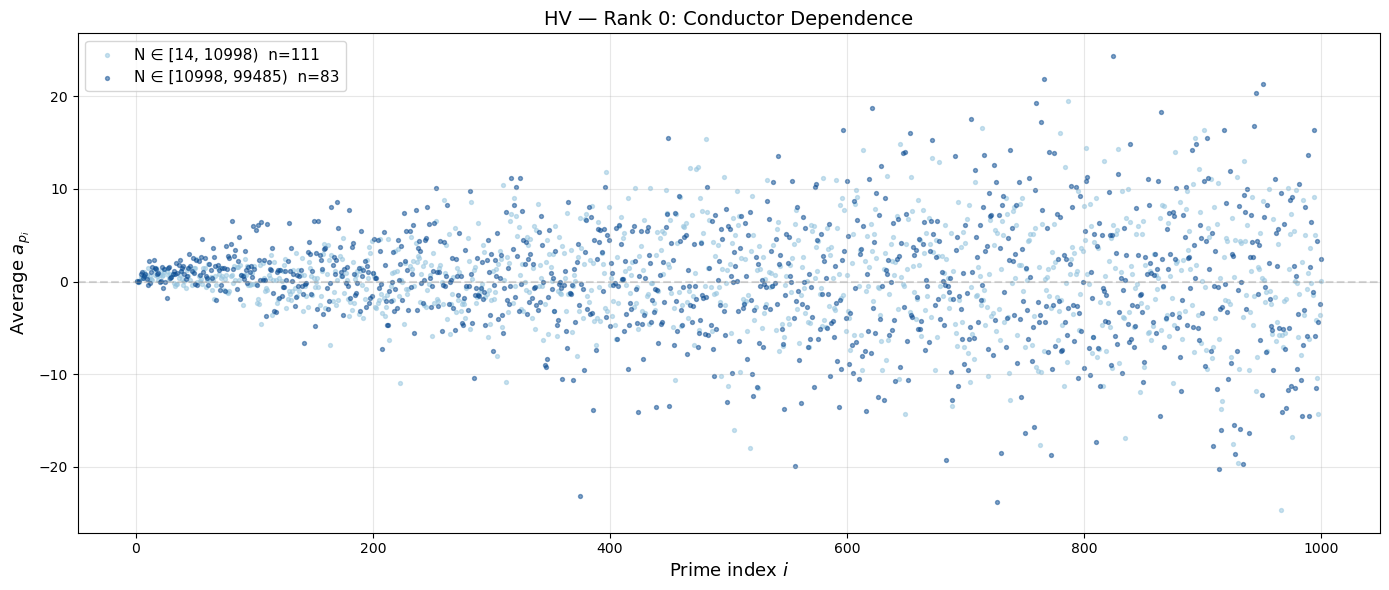

Saved Fast_Murmuration_Search/HV_conductor_overlay_rk0.png


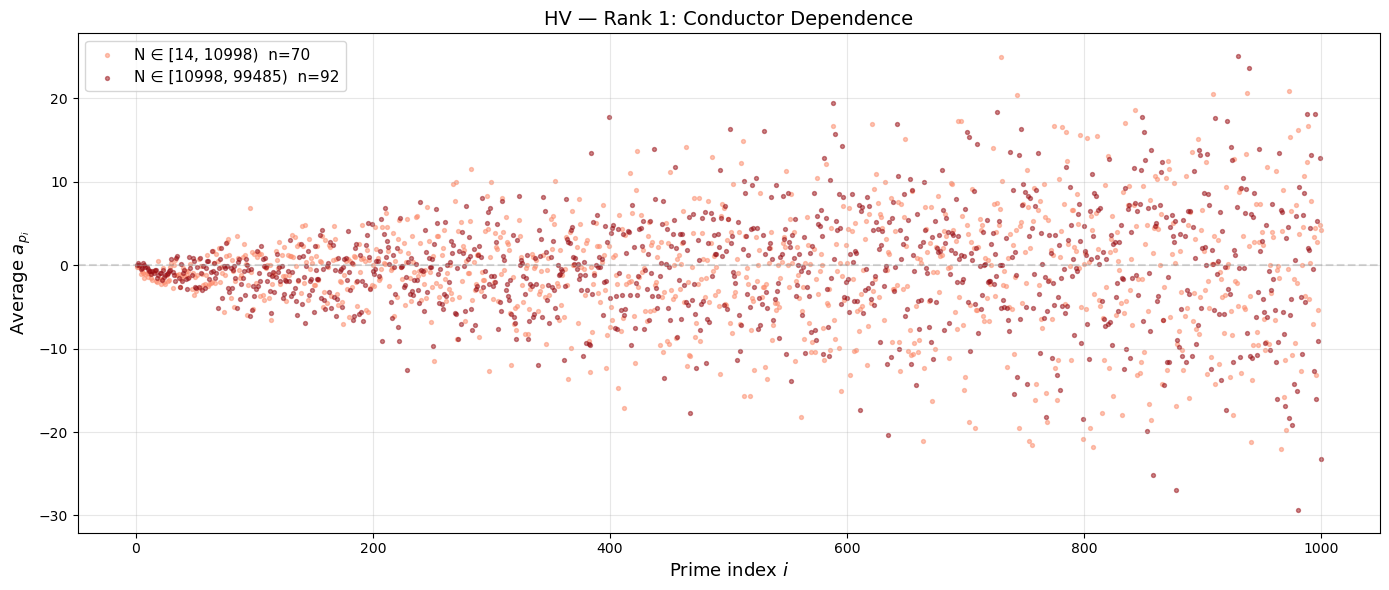

Saved Fast_Murmuration_Search/HV_conductor_overlay_rk1.png


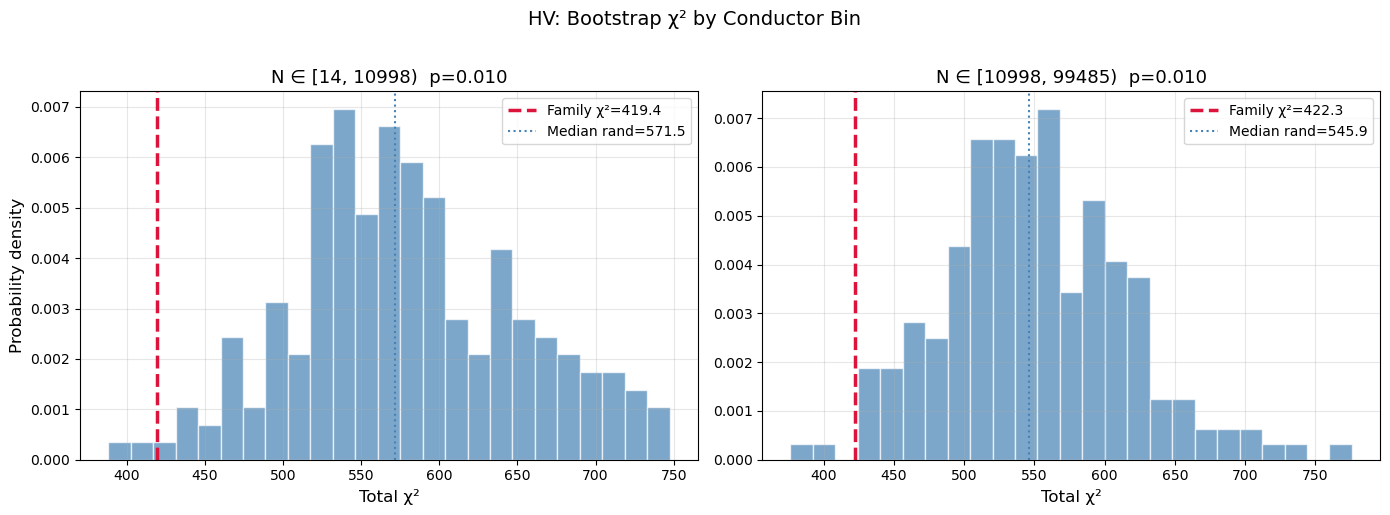

Saved Fast_Murmuration_Search/HV_conductor_bootstrap.png

CONDUCTOR SPLIT SUMMARY — HV
                 Bin    n0    n1   χ²_fam  χ²_rand   ratio   p-val
──────────────────────────────────────────────────────────────────────
[    14,  10998)    111    70    419.4    571.5 [ 10998,  99485)     83    92    422.3    545.9   N ∈ [14, 10998):  n=(111,70)  χ²_fam=419.4  χ²_rand=571.5  ratio=1.36x  p=0.0100
  N ∈ [10998, 99485):  n=(83,92)  χ²_fam=422.3  χ²_rand=545.9  ratio=1.29x  p=0.0100

✓ COMPLETE — HV
Curves: 194 rank 0, 162 rank 1
Family χ²  = 151.71
Random χ²  = 275.77 (median of 200 draws)
Cleanliness = 1.82x
p-value    = 0.0000


In [5]:
output = run_family_analysis(
    family_name="HV",
    a_coeffs={   4: -243,
    3: 324,
    2: -810,
    1: 324,
    0: -27},
    b_coeffs={6: -1458,
    5: 2916,
    4: 7290,
    3: -9720,
    2: 5346,
    1: -972,
    0: 54},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

In [20]:
highN_data = load('Fast_Murmuration_Search/HV_cond_10998_99485_avg_aps.sobj')
lowN_data = load('Fast_Murmuration_Search/HV_cond_14_10998_avg_aps')

In [29]:
lowN_aps0 = lowN_data['rk0_avg']
lowN_aps1 = lowN_data['rk1_avg']
highN_aps0 = highN_data['rk0_avg']
highN_aps1 = highN_data['rk1_avg']

In [13]:
lowN_data.keys()

dict_keys(['rk0_avg', 'rk1_avg', 'n0', 'n1', 'conductor_range', 'family_name', 'chi2_family', 'chi2_random', 'fit_rk0', 'fit_rk1', 'n_fit'])

In [22]:
ratio = N(highN_data['conductor_range'][1]/lowN_data['conductor_range'][1])

In [27]:
highp = round(1000/ratio)

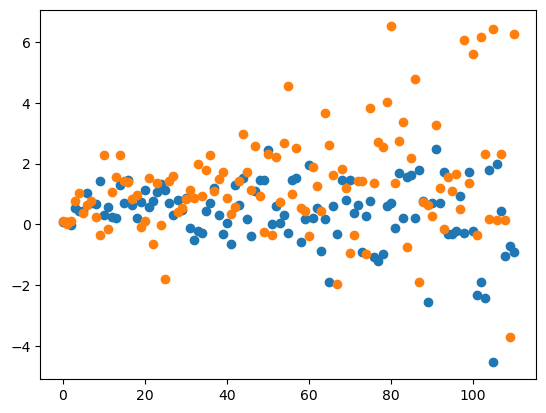

In [32]:
import matplotlib.pyplot as plt

plt.scatter(range(highp), lowN_aps0[:highp])
plt.scatter(range(highp), highN_aps0[:highp])
plt.show()

In [1]:
"""
Suite for analyzing elliptic curve families and comparing to random samples.
Includes bootstrapped chi² distribution with conductor-matched random draws.
"""
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter
import random
from scipy.optimize import curve_fit



# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100000)/curve_database_N1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")


# ============================================================================
# HELPERS
# ============================================================================

def get_isogeny_class(label):
    """Extract isogeny class from curve label: '11a1' -> '11a'"""
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]


def get_conductor(iso_label):
    """Extract integer conductor from isogeny class label: '11a' -> 11"""
    i = 0
    while i < len(iso_label) and iso_label[i].isdigit():
        i += 1
    return int(iso_label[:i])


def power_law(x, A, alpha):
    """Power law function: A * x^alpha"""
    return A * x**alpha


def fit_power_law(y, n_fit, p0, label=""):
    """
    Fit power law to first n_fit points of y.
    Returns dict with A, alpha, chi2, fit array, or None on failure.
    """
    if len(y) < n_fit:
        return None
    x = np.arange(1, n_fit + 1)
    data = y[:n_fit]
    try:
        popt, _ = curve_fit(power_law, x, data, p0=p0, maxfev=10000)
        A, alpha = popt
        fit = power_law(x, A, alpha)
        chi2 = float(np.sum((data - fit)**2))
        return {'A': A, 'alpha': alpha, 'chi2': chi2, 'fit': fit, 'popt': popt}
    except Exception as e:
        if label:
            print(f"  Fit failed for {label}: {e}")
        return None


def compute_total_chi2(rk0_avg, rk1_avg, n0, n1, n_fit):
    """Compute total chi2 from power-law fits to rank 0 and rank 1 averages."""
    res_rk0 = fit_power_law(rk0_avg, n_fit, p0=[-1, 0.5]) if n0 > 0 else None
    res_rk1 = fit_power_law(rk1_avg, n_fit, p0=[1, 0.5]) if n1 > 0 else None
    chi2 = 0.0
    if res_rk0 is not None:
        chi2 += res_rk0['chi2']
    if res_rk1 is not None:
        chi2 += res_rk1['chi2']
    return chi2, res_rk0, res_rk1


# ============================================================================
# FAMILY DEFINITION
# ============================================================================

class EllipticCurveFamily:
    """
    Define an elliptic curve family E: y^2 = x^3 + a(phi)*x + b(phi)

    Parameters
    ----------
    a_coeffs : dict  {power: coefficient}
    b_coeffs : dict  {power: coefficient}
    name : str
    """
    def __init__(self, a_coeffs, b_coeffs, name="CustomFamily"):
        self.a_coeffs = a_coeffs
        self.b_coeffs = b_coeffs
        self.name = name

        R.<phi> = QQ[]
        self.a_poly = sum(c * phi^p for p, c in a_coeffs.items())
        self.b_poly = sum(c * phi^p for p, c in b_coeffs.items())

        print(f"Family: {name}")
        print(f"  a(φ) = {self.a_poly}")
        print(f"  b(φ) = {self.b_poly}")

    def curve(self, phi_val):
        """Return EllipticCurve for a given rational phi."""
        return EllipticCurve([0, 0, 0, self.a_poly(phi_val), self.b_poly(phi_val)])


# ============================================================================
# SCAN FAMILY
# ============================================================================

def scan_family(family, phi_range_m=(-20, 21), phi_range_n=(-20, 21)):
    """
    Scan phi = m/n grid, collect isogeny classes and ap data from curve_db.
    Returns dict with iso_to_phis, iso_to_data (including conductor), ap lists, stats.
    """
    phis = set()
    for m in range(*phi_range_m):
        for n in range(*phi_range_n):
            if n != 0:
                phis.add(QQ(m) / QQ(n))
    phis = list(phis)
    print(f"Generated {len(phis)} unique phi values")

    iso_to_phis = {}
    iso_to_data = {}
    n_hits = 0
    n_misses = 0

    for phi in tqdm(phis, desc="Scanning"):
        try:
            E = family.curve(phi)
            iso = get_isogeny_class(E.label())
            if iso in curve_db:
                if iso not in iso_to_phis:
                    iso_to_phis[iso] = []
                    c = curve_db[iso]
                    iso_to_data[iso] = {
                        'rank': c['rank'],
                        'aps': c['ap_list'],
                        'conductor': get_conductor(iso),
                    }
                iso_to_phis[iso].append(phi)
                n_hits += 1
            else:
                n_misses += 1
        except Exception:
            n_misses += 1

    n_distinct = len(iso_to_phis)
    efficiency = 100.0 * n_hits / len(phis) if phis else 0

    rk0_aps = [d['aps'] for d in iso_to_data.values() if d['rank'] == 0]
    rk1_aps = [d['aps'] for d in iso_to_data.values() if d['rank'] == 1]

    print(f"\n{'='*60}")
    print(f"SCAN RESULTS: {family.name}")
    print(f"{'='*60}")
    print(f"Phis tried: {len(phis)}  |  Hits: {n_hits}  |  Misses: {n_misses}")
    print(f"Efficiency: {efficiency:.1f}%")
    print(f"Distinct isogeny classes: {n_distinct}  (redundant: {n_hits - n_distinct})")
    print(f"Rank 0: {len(rk0_aps)}  |  Rank 1: {len(rk1_aps)}")

    conductors = [d['conductor'] for d in iso_to_data.values()]
    if conductors:
        print(f"Conductor range: {min(conductors)} – {max(conductors)}")

    mults = Counter(len(v) for v in iso_to_phis.values())
    print("Multiplicity distribution:")
    for m in sorted(mults):
        print(f"  {m}x: {mults[m]}")

    return {
        'iso_to_phis': iso_to_phis,
        'iso_to_data': iso_to_data,
        'rk0_aps': rk0_aps,
        'rk1_aps': rk1_aps,
        'stats': {
            'n_phis': len(phis), 'n_hits': n_hits,
            'n_misses': n_misses, 'n_distinct': n_distinct,
            'efficiency': efficiency,
        },
    }


# ============================================================================
# BOOTSTRAP COMPARISON (conductor-matched)
# ============================================================================

def bootstrap_random_chi2(n0, n1, n_fit, n_bootstrap=200, seed=42,
                          cond_range=None):
    """
    Draw n_bootstrap random samples from curve_db and return array of total chi2.

    Parameters
    ----------
    cond_range : tuple (lo, hi) or None
        If given, restrict the random pool to conductors in [lo, hi].
    """
    if cond_range is not None:
        lo, hi = cond_range
        rk0_pool = [iso for iso, d in curve_db.items()
                     if d['rank'] == 0 and lo <= get_conductor(iso) <= hi]
        rk1_pool = [iso for iso, d in curve_db.items()
                     if d['rank'] == 1 and lo <= get_conductor(iso) <= hi]
    else:
        rk0_pool = [iso for iso, d in curve_db.items() if d['rank'] == 0]
        rk1_pool = [iso for iso, d in curve_db.items() if d['rank'] == 1]

    actual_n0 = min(n0, len(rk0_pool))
    actual_n1 = min(n1, len(rk1_pool))
    if actual_n0 < n0 or actual_n1 < n1:
        print(f"  ⚠ Pool limited: using {actual_n0}/{n0} rk0, {actual_n1}/{n1} rk1")
    if actual_n0 + actual_n1 == 0:
        return np.array([])

    rng = random.Random(int(seed))
    chi2_samples = []

    for _ in tqdm(range(int(n_bootstrap)), desc="Bootstrap"):
        chi2 = 0.0
        if actual_n0 > 0:
            avg = np.mean([curve_db[iso]['ap_list']
                           for iso in rng.sample(rk0_pool, actual_n0)], axis=0)
            res = fit_power_law(avg, n_fit, p0=[-1, 0.5])
            if res is not None:
                chi2 += res['chi2']
        if actual_n1 > 0:
            avg = np.mean([curve_db[iso]['ap_list']
                           for iso in rng.sample(rk1_pool, actual_n1)], axis=0)
            res = fit_power_law(avg, n_fit, p0=[1, 0.5])
            if res is not None:
                chi2 += res['chi2']
        chi2_samples.append(chi2)

    return np.array(chi2_samples)


# ============================================================================
# MAIN DRIVER
# ============================================================================

def run_family_analysis(family_name, a_coeffs, b_coeffs,
                        phi_range_m=(-20, 21), phi_range_n=(-20, 21),
                        n_fit=100, n_bootstrap=200, seed=42):
    """
    Full pipeline:
      1. Define family  →  2. Scan  →  3. Fit  →  4. Bootstrap  →  5. Plots

    Random draws in the bootstrap are restricted to the same conductor
    range as the family's curves.

    Outputs are saved to Fast_Murmuration_Search/{family_name}/.
    """
    # --- Create family ---
    try:
        family = EllipticCurveFamily(a_coeffs, b_coeffs, name=family_name)
    except Exception as e:
        print(f"❌ Failed to create family: {e}")
        return None

    tag = family_name.replace(" ", "_")
    output_dir = f'Fast_Murmuration_Search/{tag}'
    os.makedirs(output_dir, exist_ok=True)

    # --- Step 1: Scan ---
    print(f"\n{'='*60}")
    print(f"STEP 1: SCANNING {family_name}")
    print(f"{'='*60}")

    scan = scan_family(family, phi_range_m=phi_range_m, phi_range_n=phi_range_n)
    n0 = len(scan['rk0_aps'])
    n1 = len(scan['rk1_aps'])

    if n0 + n1 < 10:
        print(f"\n❌ Only {n0 + n1} curves found — too few for murmuration analysis.")
        print("Try expanding phi ranges or checking coefficient formulas.")
        return None

    rk0_avg = np.mean(scan['rk0_aps'], axis=0) if n0 > 0 else np.array([])
    rk1_avg = np.mean(scan['rk1_aps'], axis=0) if n1 > 0 else np.array([])

    # Determine family conductor range for matched bootstrap
    conductors = [d['conductor'] for d in scan['iso_to_data'].values()]
    cond_lo, cond_hi = min(conductors), max(conductors)
    print(f"Conductor range for bootstrap matching: [{cond_lo}, {cond_hi}]")

    # Save averages
    save_path = f'{output_dir}/{tag}_avg_aps.sobj'
    save({'rk0_avg': rk0_avg, 'rk1_avg': rk1_avg,
          'n0': n0, 'n1': n1,
          'family_name': family_name,
          'a_coeffs': a_coeffs, 'b_coeffs': b_coeffs,
          'conductor_range': (cond_lo, cond_hi)}, save_path)
    print(f"Saved averages to {save_path}")

    # --- Step 2: Fit family ---
    print(f"\n{'='*60}")
    print(f"STEP 2: FITTING {family_name}")
    print(f"{'='*60}")

    available = []
    if n0 > 0:
        available.append(len(rk0_avg))
    if n1 > 0:
        available.append(len(rk1_avg))
    N_FIT = min(int(n_fit), *available)

    chi2_fam, fit_rk0, fit_rk1 = compute_total_chi2(rk0_avg, rk1_avg, n0, n1, N_FIT)

    if fit_rk0 is not None:
        print(f"Rank 0: {fit_rk0['A']:.4f} · i^{fit_rk0['alpha']:.4f}  (χ²={fit_rk0['chi2']:.2f})")
    if fit_rk1 is not None:
        print(f"Rank 1: {fit_rk1['A']:.4f} · i^{fit_rk1['alpha']:.4f}  (χ²={fit_rk1['chi2']:.2f})")
    print(f"Total family χ² = {chi2_fam:.2f}")

    # --- Step 3: Bootstrap (conductor-matched) ---
    print(f"\n{'='*60}")
    print(f"STEP 3: BOOTSTRAP ({n_bootstrap} draws, N ∈ [{cond_lo}, {cond_hi}])")
    print(f"{'='*60}")

    chi2_rand = bootstrap_random_chi2(n0, n1, N_FIT,
                                       n_bootstrap=n_bootstrap, seed=seed,
                                       cond_range=(cond_lo, cond_hi))

    if len(chi2_rand) == 0:
        print("❌ Bootstrap failed.")
        return None

    median_rand = float(np.median(chi2_rand))
    mean_rand = float(np.mean(chi2_rand))
    std_rand = float(np.std(chi2_rand))
    p_value = float(np.mean(chi2_rand <= chi2_fam))

    print(f"\nRandom χ² distribution ({n_bootstrap} draws):")
    print(f"  mean  = {mean_rand:.2f}  ±  {std_rand:.2f}")
    print(f"  median = {median_rand:.2f}")
    print(f"  min   = {float(np.min(chi2_rand)):.2f}  |  max = {float(np.max(chi2_rand)):.2f}")
    print(f"\nFamily χ² = {chi2_fam:.2f}")
    if chi2_fam > 0:
        print(f"Median random / family = {median_rand / chi2_fam:.2f}x cleaner")
    print(f"p-value (fraction of random ≤ family χ²) = {p_value:.4f}")

    # Save bootstrap data
    boot_path = f'{output_dir}/{tag}_bootstrap.sobj'
    save({'chi2_family': chi2_fam, 'chi2_random': chi2_rand,
          'n_bootstrap': int(n_bootstrap), 'n_fit': N_FIT,
          'n0': n0, 'n1': n1, 'seed': int(seed),
          'fit_rk0': fit_rk0, 'fit_rk1': fit_rk1,
          'conductor_range': (cond_lo, cond_hi)}, boot_path)
    print(f"Saved bootstrap data to {boot_path}")

    # --- Step 4: Plots ---
    print(f"\n{'='*60}")
    print("STEP 4: PLOTTING")
    print(f"{'='*60}")

    x_fit = np.arange(1, N_FIT + 1)

    # Plot A: Family data with power-law fits
    n_primes = max(len(rk0_avg) if n0 > 0 else 0, len(rk1_avg) if n1 > 0 else 0)
    x_all = np.arange(1, n_primes + 1)

    plt.figure(figsize=(14, 6))
    if n0 > 0:
        plt.scatter(x_all[:len(rk0_avg)], rk0_avg, s=8, alpha=0.6,
                    label=f'Rank 0 (n={n0})')
        if fit_rk0 is not None:
            plt.plot(x_fit, fit_rk0['fit'], 'b-', lw=2,
                     label=f"Fit: {fit_rk0['A']:.3f} i^{fit_rk0['alpha']:.3f}")
    if n1 > 0:
        plt.scatter(x_all[:len(rk1_avg)], rk1_avg, s=8, alpha=0.6,
                    label=f'Rank 1 (n={n1})')
        if fit_rk1 is not None:
            plt.plot(x_fit, fit_rk1['fit'], 'r-', lw=2,
                     label=f"Fit: {fit_rk1['A']:.3f} i^{fit_rk1['alpha']:.3f}")
    plt.axhline(0, color='gray', ls='--', alpha=0.3)
    plt.axvline(N_FIT, color='gray', ls=':', alpha=0.5, label=f'Fit range (i<{N_FIT})')
    plt.xlabel('Prime index $i$', fontsize=13)
    plt.ylabel(r'Average $a_{p_i}$', fontsize=13)
    plt.title(f'{family_name}: Power-Law Fits (first {N_FIT} primes)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path_fit = f'{output_dir}/{tag}_power_law_fit.png'
    plt.savefig(path_fit, dpi=150)
    plt.show()
    print(f"Saved {path_fit}")

    # Plot B: Side-by-side family vs one random draw (conductor-matched)
    rng_plot = random.Random(int(seed))
    rk0_pool = [iso for iso, d in curve_db.items()
                if d['rank'] == 0 and cond_lo <= get_conductor(iso) <= cond_hi]
    rk1_pool = [iso for iso, d in curve_db.items()
                if d['rank'] == 1 and cond_lo <= get_conductor(iso) <= cond_hi]

    rk0_avg_r = np.array([])
    rk1_avg_r = np.array([])
    if n0 > 0 and len(rk0_pool) >= n0:
        rk0_avg_r = np.mean([curve_db[iso]['ap_list']
                              for iso in rng_plot.sample(rk0_pool, n0)], axis=0)
    if n1 > 0 and len(rk1_pool) >= n1:
        rk1_avg_r = np.mean([curve_db[iso]['ap_list']
                              for iso in rng_plot.sample(rk1_pool, n1)], axis=0)
    chi2_one_rand, fit_rk0_r, fit_rk1_r = compute_total_chi2(
        rk0_avg_r, rk1_avg_r, n0, n1, N_FIT)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    for ax, (r0a, r1a, f0, f1, chi2_val, title_str) in zip(
        axes,
        [(rk0_avg, rk1_avg, fit_rk0, fit_rk1, chi2_fam, f'{family_name}'),
         (rk0_avg_r, rk1_avg_r, fit_rk0_r, fit_rk1_r, chi2_one_rand, 'Random Sample')]):

        if n0 > 0 and len(r0a) > 0:
            ax.scatter(np.arange(1, len(r0a)+1), r0a, s=8, alpha=0.6, label='Rank 0')
            if f0 is not None:
                ax.plot(x_fit, f0['fit'], 'b-', lw=2)
        if n1 > 0 and len(r1a) > 0:
            ax.scatter(np.arange(1, len(r1a)+1), r1a, s=8, alpha=0.6, label='Rank 1')
            if f1 is not None:
                ax.plot(x_fit, f1['fit'], 'r-', lw=2)
        ax.axhline(0, color='gray', ls='--', alpha=0.3)
        ax.axvline(N_FIT, color='gray', ls=':', alpha=0.5)
        ax.set_xlabel('Prime index', fontsize=13)
        ax.set_title(f'{title_str} (χ²={chi2_val:.1f})', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Average $a_p$', fontsize=13)
    plt.tight_layout()
    path_cmp = f'{output_dir}/{tag}_vs_random.png'
    plt.savefig(path_cmp, dpi=150)
    plt.show()
    print(f"Saved {path_cmp}")

    # Plot C: Bootstrap histogram
    plt.figure(figsize=(10, 6))
    plt.hist(chi2_rand, bins=30, density=True, alpha=0.7, color='steelblue',
             edgecolor='white', label=f'Random draws (n={int(n_bootstrap)})')
    plt.axvline(chi2_fam, color='crimson', lw=2.5, ls='--',
                label=f'{family_name}  χ²={chi2_fam:.1f}')
    plt.axvline(median_rand, color='steelblue', lw=1.5, ls=':',
                label=f'Median random  χ²={median_rand:.1f}')
    plt.xlabel('Total χ² (power-law residual)', fontsize=13)
    plt.ylabel('Probability density', fontsize=13)
    plt.title(f'{family_name} vs Random: Bootstrap χ² Distribution '
              f'(p={p_value:.3f})', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path_boot = f'{output_dir}/{tag}_bootstrap_chi2.png'
    plt.savefig(path_boot, dpi=150)
    plt.show()
    print(f"Saved {path_boot}")

    # --- Write results summary ---
    clarity = median_rand / chi2_fam if chi2_fam > 0 else float('inf')
    results_path = f'{output_dir}/{tag}_results.txt'
    with open(results_path, 'w') as f:
        f.write(f"Family: {family_name}\n")
        f.write(f"a(φ) coeffs: {a_coeffs}\n")
        f.write(f"b(φ) coeffs: {b_coeffs}\n")
        f.write(f"Phi grid: m ∈ {phi_range_m}, n ∈ {phi_range_n}\n")
        f.write(f"\n")
        f.write(f"Curves: {n0} rank 0, {n1} rank 1\n")
        f.write(f"Conductor range: [{cond_lo}, {cond_hi}]\n")
        f.write(f"Primes fitted: {N_FIT}\n")
        f.write(f"\n")
        if fit_rk0 is not None:
            f.write(f"Rank 0 fit: {fit_rk0['A']:.6f} · i^{fit_rk0['alpha']:.6f}  "
                    f"(χ² = {fit_rk0['chi2']:.4f})\n")
        if fit_rk1 is not None:
            f.write(f"Rank 1 fit: {fit_rk1['A']:.6f} · i^{fit_rk1['alpha']:.6f}  "
                    f"(χ² = {fit_rk1['chi2']:.4f})\n")
        f.write(f"\n")
        f.write(f"Family χ²        = {chi2_fam:.4f}\n")
        f.write(f"Random χ² median = {median_rand:.4f}  "
                f"(mean = {mean_rand:.4f} ± {std_rand:.4f}, "
                f"n_bootstrap = {int(n_bootstrap)})\n")
        f.write(f"Clarity ratio    = {clarity:.4f}\n")
        f.write(f"p-value          = {p_value:.4f}\n")
    print(f"Saved results to {results_path}")

    # --- Final summary ---
    print(f"\n{'='*60}")
    print(f"✓ COMPLETE — {family_name}")
    print(f"{'='*60}")
    print(f"Curves: {n0} rank 0, {n1} rank 1")
    print(f"Conductor range: [{cond_lo}, {cond_hi}]")
    print(f"Family χ²  = {chi2_fam:.2f}")
    print(f"Random χ²  = {median_rand:.2f} (median of {int(n_bootstrap)} draws)")
    if chi2_fam > 0:
        print(f"Cleanliness = {median_rand / chi2_fam:.2f}x")
    print(f"p-value    = {p_value:.4f}")

    return {
        'scan': scan,
        'fit_rk0': fit_rk0,
        'fit_rk1': fit_rk1,
        'chi2_family': chi2_fam,
        'chi2_random_samples': chi2_rand,
        'median_random_chi2': median_rand,
        'p_value': p_value,
        'n0': n0, 'n1': n1, 'n_fit': N_FIT,
        'conductor_range': (cond_lo, cond_hi),
    }


# ============================================================================
# READY
# ============================================================================
print("\n" + "="*60)
print("MURMURATION SUITE READY")
print("="*60)
print("""
Usage:
    result = run_family_analysis(
        "Hulek-Verrill",
        a_coeffs={...},
        b_coeffs={...},
        phi_range_m=(-30, 31),
        phi_range_n=(-30, 31),
        n_fit=100,
        n_bootstrap=200,
    )

Outputs saved to Fast_Murmuration_Search/{family_name}/:
  - {tag}_avg_aps.sobj       averaged ap data
  - {tag}_bootstrap.sobj     bootstrap chi2 samples
  - {tag}_results.txt        chi2 values and clarity ratio
  - {tag}_*.png              plots
""")

Loading curve database...
✓ Loaded curve_db with 437226 isogeny classes

MURMURATION SUITE READY

Usage:
    result = run_family_analysis(
        "Hulek-Verrill",
        a_coeffs={...},
        b_coeffs={...},
        phi_range_m=(-30, 31),
        phi_range_n=(-30, 31),
        n_fit=100,
        n_bootstrap=200,
    )

Outputs saved to Fast_Murmuration_Search/{family_name}/:
  - {tag}_avg_aps.sobj       averaged ap data
  - {tag}_bootstrap.sobj     bootstrap chi2 samples
  - {tag}_results.txt        chi2 values and clarity ratio
  - {tag}_*.png              plots



Family: HV
  a(φ) = -243*phi^4 + 324*phi^3 - 810*phi^2 + 324*phi - 27
  b(φ) = -1458*phi^6 + 2916*phi^5 + 7290*phi^4 - 9720*phi^3 + 5346*phi^2 - 972*phi + 54

STEP 1: SCANNING HV
Generated 511 unique phi values


Scanning: 100%|███████████████████████████████████████████████████████████████████████| 511/511 [00:40<00:00, 12.47it/s]



SCAN RESULTS: HV
Phis tried: 511  |  Hits: 427  |  Misses: 84
Efficiency: 83.6%
Distinct isogeny classes: 363  (redundant: 64)
Rank 0: 194  |  Rank 1: 162
Conductor range: 14 – 99484
Multiplicity distribution:
  1x: 308
  2x: 49
  3x: 4
  4x: 1
  5x: 1
Conductor range for bootstrap matching: [14, 99484]
Saved averages to Fast_Murmuration_Search/HV/HV_avg_aps.sobj

STEP 2: FITTING HV
Rank 0: 0.3649 · i^0.2199  (χ²=53.40)
Rank 1: -0.5106 · i^0.1622  (χ²=98.31)
Total family χ² = 151.71

STEP 3: BOOTSTRAP (200 draws, N ∈ [14, 99484])


Bootstrap:  32%|██████████████████████▋                                                | 64/200 [00:01<00:03, 36.59it/s]/projects/ruehlehet/luigi/miniconda3/envs/sage-build/lib/python3.12/json/encoder.py:258: RuntimeWarning: cypari2 leaked 22665682881392 bytes on the PARI stack
  return _iterencode(o, 0)
Bootstrap: 100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:05<00:00, 36.29it/s]



Random χ² distribution (200 draws):
  mean  = 273.22  ±  32.25
  median = 271.95
  min   = 208.36  |  max = 376.97

Family χ² = 151.71
Median random / family = 1.79x cleaner
p-value (fraction of random ≤ family χ²) = 0.0000
Saved bootstrap data to Fast_Murmuration_Search/HV/HV_bootstrap.sobj

STEP 4: PLOTTING


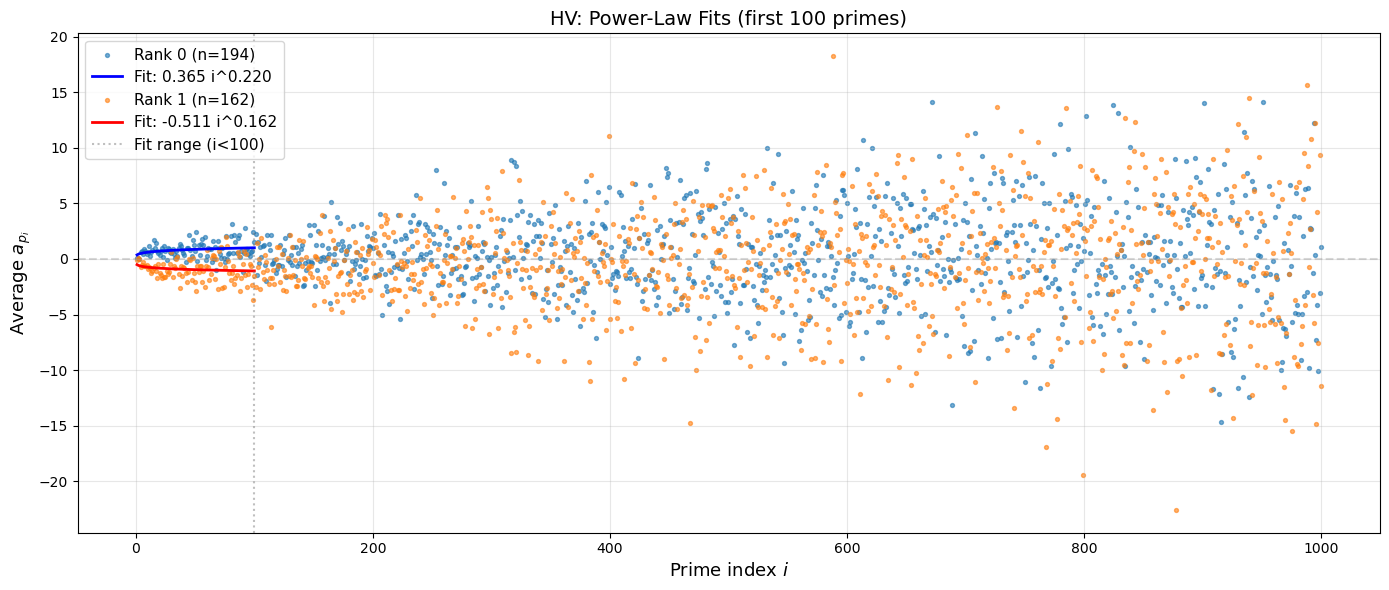

Saved Fast_Murmuration_Search/HV/HV_power_law_fit.png


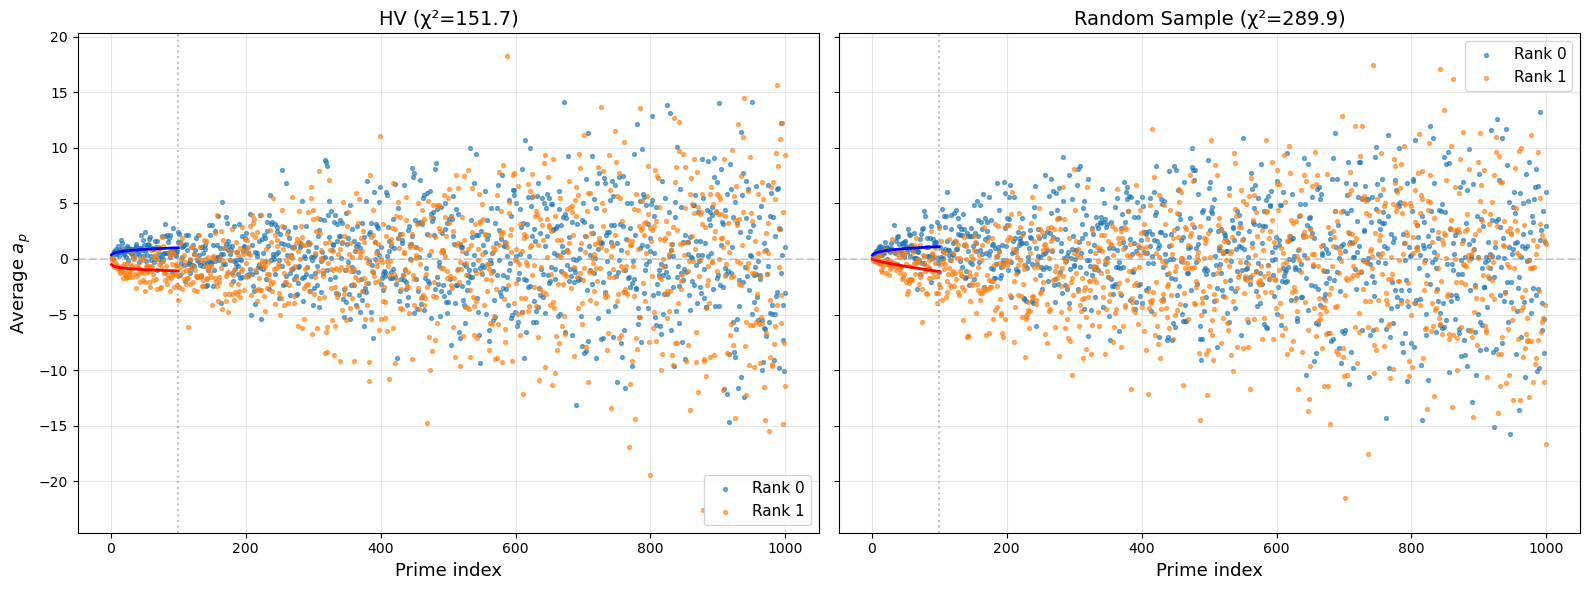

Saved Fast_Murmuration_Search/HV/HV_vs_random.png


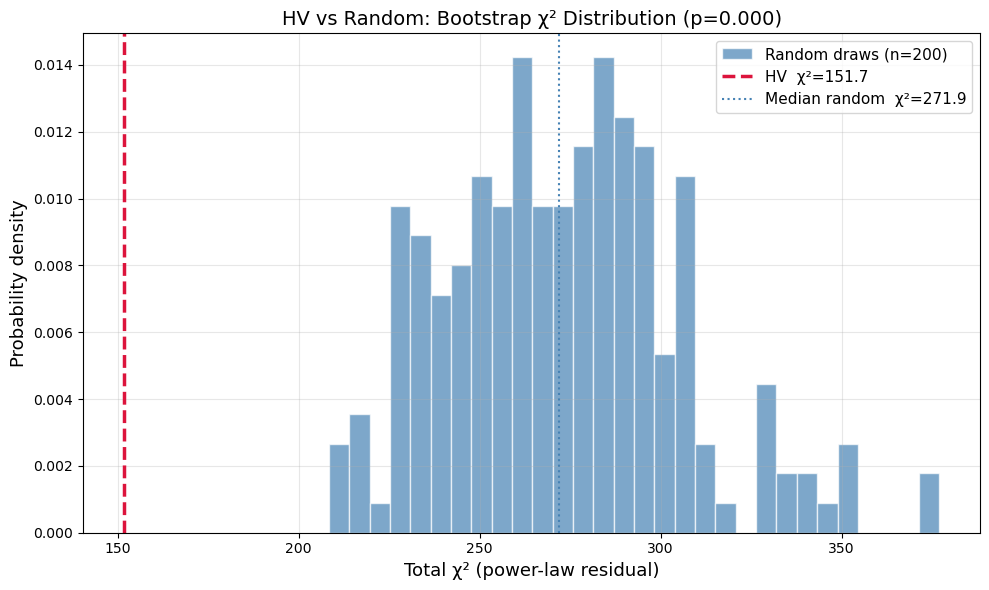

Saved Fast_Murmuration_Search/HV/HV_bootstrap_chi2.png
Saved results to Fast_Murmuration_Search/HV/HV_results.txt

✓ COMPLETE — HV
Curves: 194 rank 0, 162 rank 1
Conductor range: [14, 99484]
Family χ²  = 151.71
Random χ²  = 271.95 (median of 200 draws)
Cleanliness = 1.79x
p-value    = 0.0000


In [2]:
output = run_family_analysis(
    family_name="HV",
    a_coeffs={   4: -243,
    3: 324,
    2: -810,
    1: 324,
    0: -27},
    b_coeffs={6: -1458,
    5: 2916,
    4: 7290,
    3: -9720,
    2: 5346,
    1: -972,
    0: 54},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)